<h2 style="color: #355dd8ff;">MINI BLOOMERG</h1> 

##### Teamleiter/Haneul
* ##### Material vorbereiten,  Codieren,  Rede halten
##### Mitarbeiter/Edil, Artem
* ##### Codieren

> <h3 style="color: #4a6cd0ff;">Anlass&Ziel</h3>
* ##### Wirtschaftsindikatoren, Nachrichten und unzählige Börsen-Communities überschwemmen uns täglich mit Informationen, die unsere Leidenschaft und Urteilsfähigkeit betrüben können. Oft lassen wir uns daher durch die süße Schokolade direkt vor unseren Augen ablenken. 
* ##### Doch ein Unternehmen ist weit mehr als nicht ein einzelnes Stück Schokolade sondern gleich eine großen Schokoladenfabrik, die im Einklang mit der Zeit verschiedenste Sorten entwickelt und neue Marktstrategien erprobt. 
* ##### Dieses Projekt verfolgt dem Ziel, mithilfe mathematisch-statistischer Methoden basierend auf die Finanzberichtedie finanzielle Status und Stabilität ausgewählter Unternehmen zu beleuchten und darauf aufbauend eine stabile Grundlage für langfristige Investitionsstrategien zu schaffen.  

> <h3 style="color: #4a6cd0ff;">Verlauf</h3>
* <h5 style="color : dodgerblue;">Unternehmensbewertung als Indikator für die Gesundheit des Portfolios </h5>
* <h5 style="color : dodgerblue;">Einflussanalyse ausgewählter Kennzahlen auf das Kurs-Gewinn-Verhältnis </h5>

<h2 style="color : dodgerblue;">Unternehmensbewertung als Indikator für die Gesundheit des Portfolios</h2> 

> > <h3 style="color: #1f71b5ff;">Ziel</h3>
* ##### Die Unternehmen sollen mithilfe von einfachen Daten aus den Finanzberichten in einer Zeitreihe analysiert werden. Dabei werden Korrelationen durch Heatmap untersucht und Stärken sowie Schwächen durch Radar Chart identifiziert, um die Unternehmenstypen ( wachstumsorientiert, stabil usw) zu klassifizieren.


> > <h3 style="color: #1f71b5ff">Verlauf</h3>
##### 1. Yfinance 
##### 2. Finanzkennzahlen    
##### 3. Lineplot
##### 4. Heatmap
##### 5. Radar Chart(Absolute Evaluation)
##### 6. Robust Zscore(Relative Evaluation) 



### 1. Yfinance 
##### Daten für die Berechnung aufbereiten 

> #### Microsoft

In [15]:
# Packet importieren
import pandas as pd
import yfinance as yf

#Finanzdaten aus 'yfinance' abrufen 
msft = yf.Ticker("MSFT")
financials_m = msft.income_stmt 
balance_sheet_m = msft.balance_sheet
cash_flow_m = msft.cashflow

#Fehlende Werte mithilfe der Funktion "fillna" durch Null ersezten
financials_m_filled = financials_m.fillna(0)
balance_sheet_m_filled = balance_sheet_m.fillna(0)
cash_flow_m_filled = cash_flow_m.fillna(0)

print(financials_m_filled)
print(balance_sheet_m_filled)
print(cash_flow_m_filled)

#1# die Spalten des DataFrames in das Zeitformat umwandeln
financials_m_filled.columns = pd.to_datetime(financials_m_filled.columns) 
balance_sheet_m_filled.columns = pd.to_datetime(balance_sheet_m_filled.columns) 
cash_flow_m_filled.columns = pd.to_datetime(cash_flow_m_filled.columns) 
                                                                        
print(financials_m_filled.columns)
print(balance_sheet_m_filled.columns)
print(cash_flow_m_filled.columns)

#2# die Spalten sortieren, um Zeitanalysen zu ermöglichen
financials_m_sorted = financials_m_filled.sort_index(axis=1, ascending=True) 
balance_sheet_m_sorted = balance_sheet_m_filled.sort_index(axis=1, ascending=True) 
cash_flow_m_sorted = cash_flow_m_filled.sort_index(axis=1, ascending = True) 

print(financials_m_sorted)
print(balance_sheet_m_sorted)
print(cash_flow_m_sorted)

#3# Auswahl des Zeitfensters für die Analyse
financials_bool_m = financials_m_sorted.loc[:, "2022-06-30" : "2025-06-30"] 
balance_sheet_bool_m = balance_sheet_m_sorted.loc[:, "2022-06-30" : "2025-06-30"] 
cash_flow_bool_m = cash_flow_m_sorted.loc[:, "2022-06-30" : "2025-06-30"]

print(financials_bool_m)
print(balance_sheet_bool_m)
print(cash_flow_bool_m)

                                                      2025-06-30  \
Tax Effect Of Unusual Items                        -7.708800e+07   
Tax Rate For Calcs                                  1.760000e-01   
Normalized EBITDA                                   1.606030e+11   
Total Unusual Items                                -4.380000e+08   
Total Unusual Items Excluding Goodwill             -4.380000e+08   
Net Income From Continuing Operation Net Minori...  1.018320e+11   
Reconciled Depreciation                             3.415300e+10   
Reconciled Cost Of Revenue                          8.783100e+10   
EBITDA                                              1.601650e+11   
EBIT                                                1.260120e+11   
Net Interest Income                                 2.620000e+08   
Interest Expense                                    2.385000e+09   
Interest Income                                     2.647000e+09   
Normalized Income                               

* #### Nach der Sortierung der yfinance-Daten ist zu erkennen, dass die Daten eines bestimmten Jahr sortiert sind
* #### Mithilfe von loc übersichtlich ausgewählt und geordnet werden können.


> #### Jenoptik

In [16]:
import pandas as pd
import yfinance as yf

#Datenframe
jenoptik = yf.Ticker("JEN.DE")
financials_j = jenoptik.income_stmt 
balance_sheet_j = jenoptik.balance_sheet
cash_flow_j = jenoptik.cashflow

#Fehlende Werte in 0 umwandeln
financials_j_filled = financials_j.fillna(0)
balance_sheet_j_filled = balance_sheet_j.fillna(0)
cash_flow_j_filled = cash_flow_j.fillna(0)

print(financials_j_filled)
print(balance_sheet_j_filled)
print(cash_flow_j_filled)

#Gruppieren
financials_j_filled.columns = pd.to_datetime(financials_j_filled.columns) 
balance_sheet_j_filled.columns = pd.to_datetime(balance_sheet_j_filled.columns)
cash_flow_j_filled.columns = pd.to_datetime(cash_flow_j_filled.columns)

print(financials_j_filled.columns)
print(balance_sheet_j_filled.columns)
print(cash_flow_j_filled.columns)

#Sortieren
financials_j_sorted = financials_j_filled.sort_index(axis=1, ascending=True)
balance_sheet_j_sorted = balance_sheet_j_filled.sort_index(axis=1, ascending=True)
cash_flow_j_sorted = cash_flow_j_filled.sort_index(axis=1, ascending = True)

print(financials_j_sorted)
print(balance_sheet_j_sorted)
print(cash_flow_j_sorted)

#Zeitreihen ordnen
financials_bool_j = financials_j_sorted.loc[:, "2021-12-31" : "2024-12-31"]
balance_sheet_bool_j = balance_sheet_j_sorted.loc[:, "2021-12-31" : "2024-12-31"]
cash_flow_bool_j = cash_flow_j_sorted.loc[:, "2021-12-31" : "2024-12-31"]

print(financials_bool_j)
print(balance_sheet_bool_j)
print(cash_flow_bool_j)

                                                      2024-12-31  \
Tax Effect Of Unusual Items                         9.193000e+04   
Tax Rate For Calcs                                  2.900000e-01   
Normalized EBITDA                                   2.205210e+08   
Total Unusual Items                                 3.170000e+05   
Total Unusual Items Excluding Goodwill              3.170000e+05   
Net Income From Continuing Operation Net Minori...  9.100000e+07   
Reconciled Depreciation                             7.491200e+07   
Reconciled Cost Of Revenue                          7.426390e+08   
EBITDA                                              2.208380e+08   
EBIT                                                1.459260e+08   
Net Interest Income                                -1.514800e+07   
Interest Expense                                    1.553100e+07   
Interest Income                                     7.660000e+05   
Normalized Income                               

> #### Apple

In [27]:
import pandas as pd
import yfinance as yf
import numpy as np

#Datenframe
apple = yf.Ticker("AAPL")
financials_a = apple.income_stmt 
balance_sheet_a = apple.balance_sheet
cash_flow_a = apple.cashflow

#Fehlende Werte in 0 umwandeln
financials_a_filled = financials_a.fillna(0)
balance_sheet_a_filled = balance_sheet_a.fillna(0)
cash_flow_a_filled = cash_flow_a.fillna(0)

print(financials_a_filled)
print(balance_sheet_a_filled)
print(cash_flow_a_filled)

#Gruppieren
financials_a_filled.columns = pd.to_datetime(financials_a_filled.columns) 
balance_sheet_a_filled.columns = pd.to_datetime(balance_sheet_a_filled.columns)
cash_flow_a_filled.columns = pd.to_datetime(cash_flow_a_filled.columns)

print(financials_a_filled.columns)
print(balance_sheet_a_filled.columns)
print(cash_flow_a_filled.columns)

#Sortieren
financials_a_sorted = financials_a_filled.sort_index(axis=1, ascending=True)
balance_sheet_a_sorted = balance_sheet_a_filled.sort_index(axis=1, ascending=True)
cash_flow_a_sorted = cash_flow_a_filled.sort_index(axis=1, ascending = True)

print(financials_a_sorted)
print(balance_sheet_a_sorted)
print(cash_flow_a_sorted)

#Zeitreihen ordnen
financials_bool_a = financials_a_sorted.loc[:, "2021-09-30" : "2024-09-30"]
balance_sheet_bool_a = balance_sheet_a_sorted.loc[:, "2021-09-30" : "2024-09-30"]
cash_flow_bool_a = cash_flow_a_sorted.loc[:, "2021-09-30" : "2024-09-30"]

print(financials_bool_a)
print(balance_sheet_bool_a)
print(cash_flow_bool_a)

                                                      2024-09-30  \
Tax Effect Of Unusual Items                         0.000000e+00   
Tax Rate For Calcs                                  2.410000e-01   
Normalized EBITDA                                   1.346610e+11   
Net Income From Continuing Operation Net Minori...  9.373600e+10   
Reconciled Depreciation                             1.144500e+10   
Reconciled Cost Of Revenue                          2.103520e+11   
EBITDA                                              1.346610e+11   
EBIT                                                1.232160e+11   
Net Interest Income                                 0.000000e+00   
Interest Expense                                    0.000000e+00   
Interest Income                                     0.000000e+00   
Normalized Income                                   9.373600e+10   
Net Income From Continuing And Discontinued Ope...  9.373600e+10   
Total Expenses                                  

### 2. Berechnung von Finanzkennzahlen
##### Berechnung von Finanzkennzahlen

* #### ROE : 
   ##### Dient zum Vergleich der Rentabilität zwischen Unternehmen und zeigt, wie effizient das Unternehmen das Eigenkapital einsetzt und ermöglicht den Shareholders, die Investitionsrendite leicht einzuschätzen.

* #### Debt Ratio 
  ##### Ermöglicht eine indirekte Einschätzung des Investitionsrisikos und zeigt, wie viel Leverage das Unternehmen nutzt und wie gut es Schulden zurückzahlen kann, wodurch die finanzielle Stabilität und das Risiko bewertet werden.

* #### Growth 
  ##### Bei langfristigen Investitionen ist eine kontinuierliche Wachstumsfähigkeit wichtig. Zeigt die Markt- und Wachstumspotenziale des Unternehmens, und der Umsatztrend ermöglicht eine ungefähre Prognose künftiger Erträge.

* #### Operating Margin 
  ##### Wichtig, um Kostenstruktur und Preiskonkurrenz zu verstehen. Zeigt, wie effizient das Unternehmen mit dem Kerngeschäft Gewinn erwirtschaftet.

* #### Total Assets Turnover 
  ##### Zeigt, wie effizient ein Unternehmen seine Vermögenswerte in Umsatz umsetzt. Ermöglicht die Bewertung der Betriebseffizienz und zusammen mit Wachstum die Analyse der Investitionseffizienz.

> #### Microsoft

In [28]:
# Ausgewaehlte Finanzkennzahlen : ROE, Debit Ratio, Growth, Operating Margin, Total Assets Turnover

#4# ROE
all_ROE_m = [] 
years = ["2022-06-30", "2023-06-30", "2024-06-30", "2025-06-30"] 
for i in years: 
   Net_Income = financials_bool_m.loc["Net Income", i]
   Shareholdersequity = balance_sheet_bool_m.loc["Stockholders Equity", i]
   ROE_m = (Net_Income / Shareholdersequity) * 100

   all_ROE_m.append(round(ROE_m, 2)) 
                        
   print(f'{i[:4]}_ROE : {ROE_m:.2f}%') 
print(all_ROE_m)

# Debit Ratio(Verschuldungsgrad)
all_Debit_Ratio_m = []
years = ["2022-06-30", "2023-06-30", "2024-06-30", "2025-06-30"]
for i in years:
   
   Total_Liabilities = balance_sheet_bool_m.loc["Total Liabilities Net Minority Interest", i]
   Shareholdersequity = balance_sheet_bool_m.loc["Stockholders Equity", i]
   Debit_Ratio_m = (Total_Liabilities/Shareholdersequity) * 100 

   all_Debit_Ratio_m.append(round(Debit_Ratio_m, 2))
   print(f'{i[:4]}_Debit_Ratio : {Debit_Ratio_m:.2f}%') 
print(all_Debit_Ratio_m)

#Growth(Wachstum)
all_Heute_Growth_m = []
years = ["2022-06-30", "2023-06-30", "2024-06-30", "2025-06-30"]
for i in range(1, len(years)): 

   heute_revenue = years[i]
   vergangen_revenue = years[i-1]

   Revenue_t = financials_bool_m.loc["Total Revenue", heute_revenue]
   Revenue_t_1 = financials_bool_m.loc["Total Revenue", vergangen_revenue]
   Heute_Growth_m = ((Revenue_t - Revenue_t_1)/Revenue_t_1) * 100

   all_Heute_Growth_m.append(round(Heute_Growth_m, 2))
   print(f'{heute_revenue[:4]}_Growth : {Heute_Growth_m:.2f}%') 
print(all_Heute_Growth_m)

#Operating Margin(Umsatzrentabilitaet)
all_Operating_Margin_m = []
years = ["2022-06-30", "2023-06-30", "2024-06-30", "2025-06-30"]
for i in years: 
   
   Operating_Income = financials_bool_m.loc["Operating Income", i]
   Total_Revenue = financials_bool_m.loc["Total Revenue", i]
   Operating_Margin_m = (Operating_Income/Total_Revenue) * 100

   all_Operating_Margin_m.append(round(Operating_Margin_m, 2))
   print(f'{i[:4]}_Operating_Margin : {Operating_Margin_m:.2f}%') 
print(all_Operating_Margin_m)

#Total Assets Turnover(Vermoegensumschlag)
all_Total_Assets_Turnover_m = []
years = ["2022-06-30", "2023-06-30", "2024-06-30", "2025-06-30"]
for i in range(1, len(years)):
   
   heute_total_assets = years[i]
   vergange_total_assets = years[i-1]

   Heute_Total_Assets = balance_sheet_bool_m.loc["Total Assets", heute_total_assets]
   Vergangen_Total_Assets = balance_sheet_bool_m.loc["Total Assets", vergange_total_assets]
   Average_Total_Assets = (Heute_Total_Assets + Vergangen_Total_Assets)/2

   Net_Sales = financials_bool_m.loc["Total Revenue", heute_total_assets]
   Total_Asset_Turnover_m = Net_Sales/Average_Total_Assets

   all_Total_Assets_Turnover_m.append(round(Total_Asset_Turnover_m,2))
   print(f'{heute_total_assets[:4]}_Total_Asset_Turnover : {Total_Asset_Turnover_m:.2f}%') 
print(all_Total_Assets_Turnover_m)


2022_ROE : 43.68%
2023_ROE : 35.09%
2024_ROE : 32.83%
2025_ROE : 29.65%
[np.float64(43.68), np.float64(35.09), np.float64(32.83), np.float64(29.65)]
2022_Debit_Ratio : 119.07%
2023_Debit_Ratio : 99.77%
2024_Debit_Ratio : 90.77%
2025_Debit_Ratio : 80.22%
[np.float64(119.07), np.float64(99.77), np.float64(90.77), np.float64(80.22)]
2023_Growth : 6.88%
2024_Growth : 15.67%
2025_Growth : 14.93%
[np.float64(6.88), np.float64(15.67), np.float64(14.93)]
2022_Operating_Margin : 42.06%
2023_Operating_Margin : 41.77%
2024_Operating_Margin : 44.64%
2025_Operating_Margin : 45.62%
[np.float64(42.06), np.float64(41.77), np.float64(44.64), np.float64(45.62)]
2023_Total_Asset_Turnover : 0.55%
2024_Total_Asset_Turnover : 0.53%
2025_Total_Asset_Turnover : 0.50%
[np.float64(0.55), np.float64(0.53), np.float64(0.5)]


> #### Jenoptik

In [29]:
# Kernkennzahlen nach Jahren berechnen(ROE, DR, OM, TAT)

# ROE
all_ROE_j = []
years = ["2021-12-31", "2022-12-31", "2023-12-31", "2024-12-31"]
for i in years: 
      
   Net_Income = financials_bool_j.loc["Net Income", i]
   Shareholdersequity = balance_sheet_bool_j.loc["Stockholders Equity", i]
   ROE_j = (Net_Income / Shareholdersequity) * 100
   
   all_ROE_j.append(round(ROE_j,2))

   print(f'{i[:4]}_ROE : {ROE_j:.2f}%') 
print(all_ROE_j)

# Debit Ratio(Verschuldungsgrad)
all_Debit_Ratio_j = []
years = ["2021-12-31", "2022-12-31", "2023-12-31", "2024-12-31"]
for i in years:
   
   Total_Liabilities = balance_sheet_bool_j.loc["Total Liabilities Net Minority Interest", i]
   Shareholdersequity = balance_sheet_bool_j.loc["Stockholders Equity", i]
   Debit_Ratio_j = (Total_Liabilities/Shareholdersequity) * 100 

   all_Debit_Ratio_j.append(round(Debit_Ratio_j,2))
   print(f'{i[:4]}_Debit_Ratio : {Debit_Ratio_j:.2f}%')
print(all_Debit_Ratio_j) 

#Growth(Wachstum)
all_Growth_j = []
years = ["2021-12-31", "2022-12-31", "2023-12-31", "2024-12-31"]
for i in range(1, len(years)):
   
   heute_revenue = years[i]
   vergangen_revenue = years[i-1]

   Revenue_t = financials_bool_j.loc["Total Revenue", heute_revenue]
   Revenue_t_1 = financials_bool_j.loc["Total Revenue", vergangen_revenue]
   Heute_Growth_j = ((Revenue_t - Revenue_t_1)/Revenue_t_1) * 100

   all_Growth_j.append(round(Heute_Growth_j,2))
   print(f'{heute_revenue[:4]}_Growth : {Heute_Growth_j:.2f}%') 
print(all_Growth_j)

#Operating Margin(Umsatzrentabilitaet)
all_Operating_Margin_j = []
years = ["2021-12-31", "2022-12-31", "2023-12-31", "2024-12-31"]
for i in years: 
   
   Operating_Income = financials_bool_j.loc["Operating Income", i]
   Total_Revenue = financials_bool_j.loc["Total Revenue", i]
   Operating_Margin_j = (Operating_Income/Total_Revenue) * 100

   all_Operating_Margin_j.append(round(Operating_Margin_j,2))
   print(f'{i[:4]}_Operating_Margin : {Operating_Margin_j:.2f}%') 
print(all_Operating_Margin_j)

#Total Assets Turnover(Vermoegensumschlag)
all_TAT_j = []
years = ["2021-12-31", "2022-12-31", "2023-12-31", "2024-12-31"]
for i in range(1, len(years)):
   
   heute_total_assets = years[i]
   vergange_total_assets = years[i-1]

   Heute_Total_Assets = balance_sheet_bool_j.loc["Total Assets", heute_total_assets]
   Vergangen_Total_Assets = balance_sheet_bool_j.loc["Total Assets", vergange_total_assets]
   Average_Total_Assets = (Heute_Total_Assets + Vergangen_Total_Assets)/2

   Net_Sales = financials_bool_j.loc["Total Revenue", heute_total_assets]
   Total_Asset_Turnover_j = Net_Sales/Average_Total_Assets

   all_TAT_j.append(round(Total_Asset_Turnover_j,2))
   print(f'{heute_total_assets[:4]}_Total_Asset_Turnover : {Total_Asset_Turnover_j:.2f}%') 
print(all_TAT_j)

2021_ROE : 10.68%
2022_ROE : 6.62%
2023_ROE : 8.08%
2024_ROE : 9.65%
[np.float64(10.68), np.float64(6.62), np.float64(8.08), np.float64(9.65)]
2021_Debit_Ratio : 127.16%
2022_Debit_Ratio : 99.58%
2023_Debit_Ratio : 85.17%
2024_Debit_Ratio : 80.47%
[np.float64(127.16), np.float64(99.58), np.float64(85.17), np.float64(80.47)]
2022_Growth : 30.63%
2023_Growth : 8.70%
2024_Growth : 4.67%
[np.float64(30.63), np.float64(8.7), np.float64(4.67)]
2021_Operating_Margin : 10.57%
2022_Operating_Margin : 12.13%
2023_Operating_Margin : 13.30%
2024_Operating_Margin : 12.87%
[np.float64(10.57), np.float64(12.13), np.float64(13.3), np.float64(12.87)]
2022_Total_Asset_Turnover : 0.57%
2023_Total_Asset_Turnover : 0.64%
2024_Total_Asset_Turnover : 0.66%
[np.float64(0.57), np.float64(0.64), np.float64(0.66)]


> #### Apple

In [30]:
# Kernkennzahlen nach Jahren berechnen(ROE, DR, OM, TAT)

# ROE
all_ROE_a = []
years = ["2021-09-30", "2022-09-30", "2023-09-30", "2024-09-30"]
for i in years: 
      
   Net_Income = financials_bool_a.loc["Net Income", i]
   Shareholdersequity = balance_sheet_bool_a.loc["Stockholders Equity", i]
   ROE_a = (Net_Income / Shareholdersequity) * 100

   all_ROE_a.append(round(ROE_a,2))
   print(f'{i[:4]}_ROE : {ROE_a:.2f}%') 
print(all_ROE_a)

# Debit Ratio(Verschuldungsgrad)
all_Debit_Ratio_a = []
years = ["2021-09-30", "2022-09-30", "2023-09-30", "2024-09-30"]
for i in years:
   
   Total_Liabilities = balance_sheet_bool_a.loc["Total Liabilities Net Minority Interest", i]
   Shareholdersequity = balance_sheet_bool_a.loc["Stockholders Equity", i]
   Debit_Ratio_a = (Total_Liabilities/Shareholdersequity) * 100 

   all_Debit_Ratio_a.append(round(Debit_Ratio_a,2))
   print(f'{i[:4]}_Debit_Ratio : {Debit_Ratio_a:.2f}%') 
print(all_Debit_Ratio_a)

#Growth(Wachstum)
all_Growth_a = []
years = ["2021-09-30", "2022-09-30", "2023-09-30", "2024-09-30"]
for i in range(1, len(years)):
   
   heute_revenue = years[i]
   vergangen_revenue = years[i-1]

   Revenue_t = financials_bool_a.loc["Total Revenue", heute_revenue]
   Revenue_t_1 = financials_bool_a.loc["Total Revenue", vergangen_revenue]
   Heute_Growth_a = ((Revenue_t - Revenue_t_1)/Revenue_t_1) * 100

   all_Growth_a.append(round(Heute_Growth_a,2))
   print(f'{heute_revenue[:4]}_Growth : {Heute_Growth_a:.2f}%') 
print(all_Growth_a)

#Operating Margin(Umsatzrentabilitaet)
all_Operating_Margin_a = []
years = ["2021-09-30", "2022-09-30", "2023-09-30", "2024-09-30"]
for i in years: 
   
   Operating_Income = financials_bool_a.loc["Operating Income", i]
   Total_Revenue = financials_bool_a.loc["Total Revenue", i]
   Operating_Margin_a = (Operating_Income/Total_Revenue) * 100

   all_Operating_Margin_a.append(round(Operating_Margin_a,2))
   print(f'{i[:4]}_Operating_Margin : {Operating_Margin_a:.2f}%') 
print(all_Operating_Margin_a)

#Total Assets Turnover(Vermoegensumschlag)
all_TAT_a = []
years = ["2021-09-30", "2022-09-30", "2023-09-30", "2024-09-30"]
for i in range(1, len(years)):
   
   heute_total_assets = years[i]
   vergange_total_assets = years[i-1]

   Heute_Total_Assets = balance_sheet_bool_a.loc["Total Assets", heute_total_assets]
   Vergangen_Total_Assets = balance_sheet_bool_a.loc["Total Assets", vergange_total_assets]
   Average_Total_Assets = (Heute_Total_Assets + Vergangen_Total_Assets)/2

   Net_Sales = financials_bool_a.loc["Total Revenue", heute_total_assets]
   Total_Asset_Turnover_a = Net_Sales/Average_Total_Assets

   all_TAT_a.append(round(Total_Asset_Turnover_a,2))
   print(f'{heute_total_assets[:4]}_Total_Asset_Turnover : {Total_Asset_Turnover_a:.2f}%') 
print(all_TAT_a)

2021_ROE : 150.07%
2022_ROE : 196.96%
2023_ROE : 156.08%
2024_ROE : 164.59%
[np.float64(150.07), np.float64(196.96), np.float64(156.08), np.float64(164.59)]
2021_Debit_Ratio : 456.35%
2022_Debit_Ratio : 596.15%
2023_Debit_Ratio : 467.35%
2024_Debit_Ratio : 540.88%
[np.float64(456.35), np.float64(596.15), np.float64(467.35), np.float64(540.88)]
2022_Growth : 7.79%
2023_Growth : -2.80%
2024_Growth : 2.02%
[np.float64(7.79), np.float64(-2.8), np.float64(2.02)]
2021_Operating_Margin : 29.78%
2022_Operating_Margin : 30.29%
2023_Operating_Margin : 29.82%
2024_Operating_Margin : 31.51%
[np.float64(29.78), np.float64(30.29), np.float64(29.82), np.float64(31.51)]
2022_Total_Asset_Turnover : 1.12%
2023_Total_Asset_Turnover : 1.09%
2024_Total_Asset_Turnover : 1.09%
[np.float64(1.12), np.float64(1.09), np.float64(1.09)]


### 3. Lineplot 
##### Trends in Finanzkennzahlen durch Lineplot erkennen
- Ziel ist es, die Veränderungen der Finanzkennzahlen jedes Jahres mit einem Linienplot zu beobachten und diese mit Heatmaps zu verknüpfen, um die Zusammenhänge zwischen den Variablen zu erkennen.

> #### Microsoft

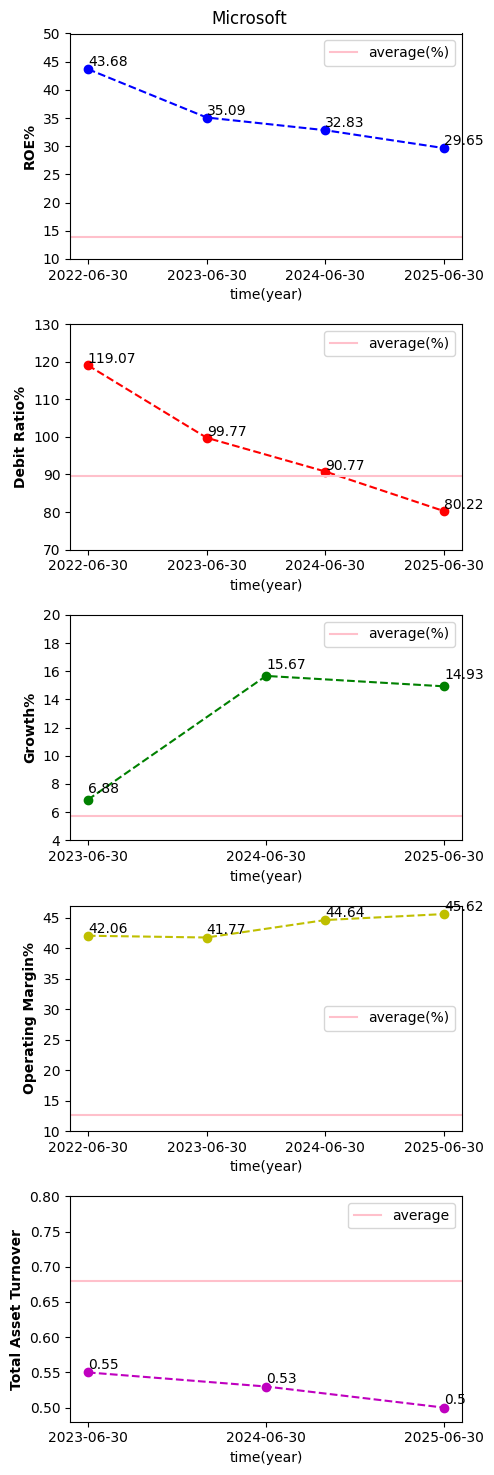

In [21]:
#Trend nach Zeitreihen durch Matplotlib
import matplotlib.pyplot as plt
fig, ax = plt.subplots(5, 1, figsize=(5, 15), sharex=False) 
years_1 = ["2022-06-30", "2023-06-30", "2024-06-30", "2025-06-30"]
years_Growth_Values = ["2023-06-30", "2024-06-30", "2025-06-30"]

ROE_Values_m = all_ROE_m
Debit_Ratio_Values_m = all_Debit_Ratio_m
Growth_Values_m = all_Heute_Growth_m
Operating_Margin_Values_m = all_Operating_Margin_m
Total_Asset_Turnover_Values_m = all_Total_Assets_Turnover_m

label_font = { 
   'fontsize' : 10,
   'fontweight' : 'bold' 
}

#ROE-Line Graph 
fig.subplots_adjust(hspace=0.5, wspace=0.3) 
                                            
ax[0].plot(years_1, ROE_Values_m, linestyle = '--', color="b", marker='o') 
ax[0].set_xlabel("time(year)")
ax[0].set_ylabel("ROE%", fontdict=label_font) 
ax[0].set_xticks(range(len(years_1)))
ax[0].set_ylim(10, 50)

for i, j in enumerate(ROE_Values_m) : 
   ax[0].text(years_1[i], j + 0.5, str(j)) 
                                         
ax[0].axhline(y=13.9, color='pink', alpha=1, linestyle='-', label='average(%)') 
                                                                                                                                                        
ax[0].legend()                                                               

#Debit Ratio
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[1].plot(years_1, Debit_Ratio_Values_m, marker = "o", linestyle = '--', color="r")
ax[1].set_xlabel("time(year)")
ax[1].set_ylabel("Debit Ratio%", fontdict=label_font)
ax[1].set_xticks(range(len(years_1)))
ax[1].set_ylim(70, 130)

for i, j in enumerate(Debit_Ratio_Values_m) :
   ax[1].text(years_1[i], j + 0.5, str(j))

ax[1].axhline(y=89.55, color='pink', alpha=1, linestyle='-', label='average(%)')
ax[1].legend()

#Growth-Line Graph
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[2].plot(years_Growth_Values, Growth_Values_m, marker = "o", linestyle = '--', color="g")
ax[2].set_xlabel("time(year)")
ax[2].set_ylabel("Growth%", fontdict=label_font)
ax[2].set_xticks(range(len(years_Growth_Values)))
ax[2].set_ylim(4, 20)

for i, j in enumerate(Growth_Values_m) :
   ax[2].text(years_Growth_Values[i], j + 0.5, str(j))

ax[2].axhline(y=5.7, color='pink', alpha=1, linestyle='-', label='average(%)')
ax[2].legend()

#Operating Margin-Line Graph 
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[3].plot(years_1, Operating_Margin_Values_m, marker = "o", linestyle = '--', color="y")
ax[3].set_xlabel("time(year)")
ax[3].set_ylabel("Operating Margin%", fontdict=label_font)
ax[3].set_xticks(range(len(years_1))) 
ax[3].set_ylim(10, 47)

for i, j in enumerate(Operating_Margin_Values_m) :
   ax[3].text(years_1[i], j + 0.5, str(j))

ax[3].axhline(y=12.7, color='pink', alpha=1, linestyle='-', label='average(%)')
ax[3].legend()

#Total Asset Turnover-Line Graph 
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[4].plot(years_Growth_Values, Total_Asset_Turnover_Values_m, marker = "o", linestyle = '--', color="m")
ax[4].set_xlabel("time(year)")
ax[4].set_ylabel("Total Asset Turnover", fontdict=label_font)
ax[4].set_xticks(range(len(years_Growth_Values)))
ax[4].set_ylim(0.48, 0.8)

for i, j in enumerate(Total_Asset_Turnover_Values_m) :
   ax[4].text(years_Growth_Values[i], j + 0.005, str(j))

ax[4].axhline(y=0.68, color='pink', alpha=1, linestyle='-', label='average')
ax[4].legend()

title_font = {
   'fontsize' : 15,
   'fontweight' : 'bold'
}

fig.suptitle('Microsoft', fontdict=title_font) 
plt.tight_layout()
plt.show()

#### ROE
* #### Im Vergleich zum Durchschnitt ist der Wert immer noch hoch, aber der ROE zeigt einen kontinuierlichen Abwärtstrend. Das bedeutet, dass das Unternehmen weniger effizient wird, die Investitionen der Aktionäre in Gewinne umzuwandeln. Während die Operating Margin gestiegen ist, sind die Verschuldungsquote und der ROE deutlich gefallen. Das deutet darauf hin, dass die Reduzierung der Schulden die finanzielle Stabilität verbessert hat, aber die geringere Hebelwirkung den ROE negativ beeinflusst hat.
#### Debit Ratio
* #### Im Jahr 2022 waren die Schulden noch höher, aber sie sind seitdem kontinuierlich gesunken. Das bedeutet, dass das Unternehmen aktiv Schulden zurückgezahlt oder Gewinnrücklagen aufgebaut hat, wodurch das Eigenkapital stark gestiegen ist. Dass der Wert unter dem Durchschnitt liegt, kann auf eine sehr hohe Stabilität gegenüber externen Schocks hindeuten.
#### Growth
* #### Ab 2023 steigt das Wachstum stark an, erreicht 2024 einen Höhepunkt und wird voraussichtlich 2025 weiterhin hoch bleiben. Das zeigt, dass sich das Unternehmen in einer Phase starken Wachstums befindet. Dies ist vermutlich das Ergebnis von Investitionen in zukunftsorientierte Technologien wie KI und Cloud-Dienste bei Microsoft.
#### Operating Margin
* #### Die Operating Margin zeigt einen stetigen Aufwärtstrend. Das bedeutet, dass die Rentabilität des Kerngeschäfts kontinuierlich verbessert wird. Gleichzeitig deutet es darauf hin, dass das Unternehmen die Betriebskosten effizient kontrolliert oder die Preissetzungsmacht gestärkt hat.
#### Total Assets Turnover
* #### Zeigt einen leichten Rückgang. Der Rückgang ist jedoch nicht groß, und aufgrund des hohen Wachstums ist es wahrscheinlich, dass dies durch vorausschauende Investitionen für zukünftiges Wachstum bedingt ist.

> #### Jenoptik

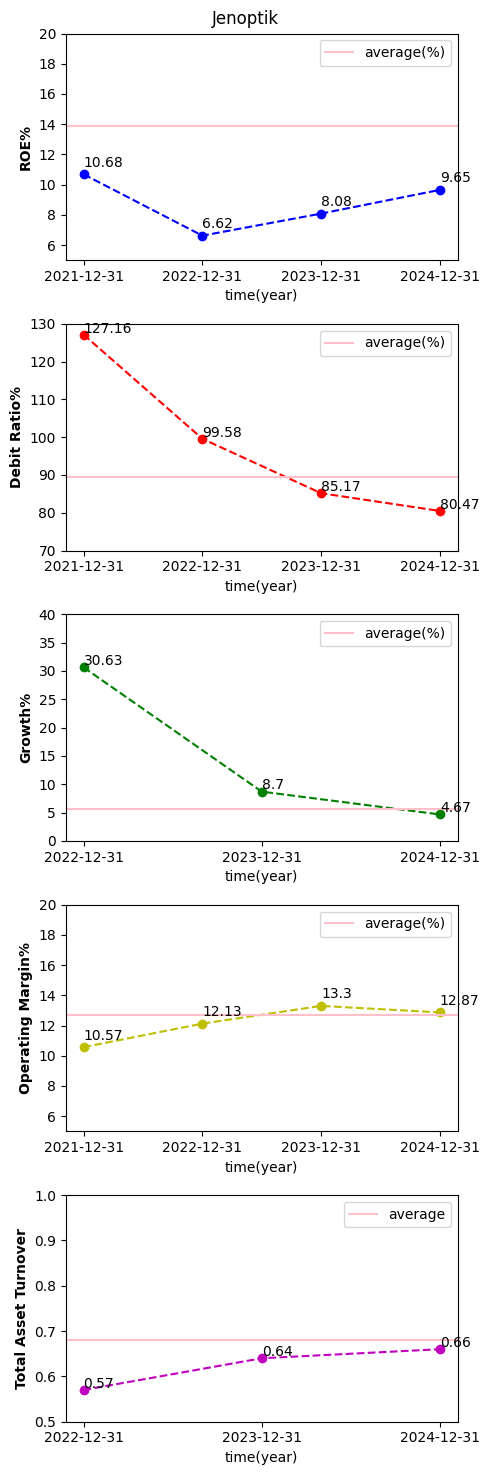

In [22]:
#Trend nach Zeitreihen durch Matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(5, 1, figsize=(5, 15), sharex=False)

years_1 = ["2021-12-31", "2022-12-31", "2023-12-31", "2024-12-31"]
years_Growth_Values = ["2022-12-31", "2023-12-31", "2024-12-31"]

ROE_Values_j = all_ROE_j
Debit_Ratio_Values_j = all_Debit_Ratio_j
Growth_Values_j = all_Growth_j
Operating_Margin_Values_j = all_Operating_Margin_j
Total_Asset_Turnover_Values_j = all_TAT_j

label_font = {
   'fontsize' : 10,
   'fontweight' : 'bold'
}

#ROE-Line Graph 
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[0].plot(years_1, ROE_Values_j, linestyle = '--', color="b", marker='o')
ax[0].set_xlabel("time(year)")
ax[0].set_ylabel("ROE%", fontdict=label_font)
ax[0].set_xticks(range(len(years_1)))
ax[0].set_ylim(5, 20)

for i, j in enumerate(ROE_Values_j) :
   ax[0].text(years_1[i], j + 0.5, str(j))

ax[0].axhline(y=13.9, color='pink', alpha=1, linestyle='-', label='average(%)')
ax[0].legend()

#Debit Ratio-Line Graph
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[1].plot(years_1, Debit_Ratio_Values_j, marker = "o", linestyle = '--', color="r")
ax[1].set_xlabel("time(year)")
ax[1].set_ylabel("Debit Ratio%", fontdict=label_font)
ax[1].set_xticks(range(len(years_1)))
ax[1].set_ylim(70, 130)

for i, j in enumerate(Debit_Ratio_Values_j) :
   ax[1].text(years_1[i], j + 0.5, str(j))

ax[1].axhline(y=89.55, color='pink', alpha=1, linestyle='-', label='average(%)')
ax[1].legend()

#Growth-Line Graph
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[2].plot(years_Growth_Values, Growth_Values_j, marker = "o", linestyle = '--', color="g")
ax[2].set_xlabel("time(year)")
ax[2].set_ylabel("Growth%", fontdict=label_font)
ax[2].set_xticks(range(len(years_Growth_Values)))
ax[2].set_ylim(0, 40)

for i, j in enumerate(Growth_Values_j) :
   ax[2].text(years_Growth_Values[i], j + 0.5, str(j))

ax[2].axhline(y=5.7, color='pink', alpha=1, linestyle='-', label='average(%)')
ax[2].legend()

#Operating Margin-Line Graph 
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[3].plot(years_1, Operating_Margin_Values_j, marker = "o", linestyle = '--', color="y")
ax[3].set_xlabel("time(year)")
ax[3].set_ylabel("Operating Margin%", fontdict=label_font)
ax[3].set_xticks(range(len(years_1))) 
ax[3].set_ylim(5, 20)

for i, j in enumerate(Operating_Margin_Values_j) :
   ax[3].text(years_1[i], j + 0.5, str(j))

ax[3].axhline(y=12.7, color='pink', alpha=1, linestyle='-', label='average(%)')
ax[3].legend()

#Total Asset Turnover-Line Graph 
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[4].plot(years_Growth_Values, Total_Asset_Turnover_Values_j, marker = "o", linestyle = '--', color="m")
ax[4].set_xlabel("time(year)")
ax[4].set_ylabel("Total Asset Turnover", fontdict=label_font)
ax[4].set_xticks(range(len(years_Growth_Values)))
ax[4].set_ylim(0.50, 1)

for i, j in enumerate(Total_Asset_Turnover_Values_j) :
   ax[4].text(years_Growth_Values[i], j + 0.005, str(j))

ax[4].axhline(y=0.68, color='pink', alpha=1, linestyle='-', label='average')
ax[4].legend()

title_font = {
   'fontsize' : 15,
   'fontweight' : 'bold'
}

fig.suptitle('Jenoptik', fontdict=title_font)
plt.tight_layout()
plt.show()

#### ROE
* #### Von 2021 bis 2022 fiel der ROE, aber seit 2022 zeigt er wieder einen Aufwärtstrend. Die kontinuierliche Erholung ist ein positives Signal, dass die Gewinnkraft im Verhältnis zum Eigenkapital der Aktionäre wieder verbessert wird. Da sowohl die Operating Margin als auch der Total Assets Turnover steigen, zeigt dies, dass Rentabilität und Effizienz der Kapitalnutzung zunehmen, was den ROE wieder steigen lässt.
#### Debit Ratio
* #### Zeigt einen kontinuierlichen starken Rückgang. Dies bedeutet, dass das Unternehmen aktiv Schulden zurückgezahlt oder Gewinnrücklagen gebildet hat, wodurch das Eigenkapital stark gestiegen ist. Eine deutlich verbesserte Finanzstabilität deutet auf hohe Sicherheit hin.
#### Growth
* #### 2022 zeigte noch starkes Wachstum, aber danach ist es kontinuierlich rückläufig. Dies kann darauf hinweisen, dass das Unternehmen aufgrund zunehmender Marktkonkurrenz oder Marktreife Schwierigkeiten hat, den Umsatz stark zu steigern.
#### Operating Margin
* #### Von 2021 bis 2023 stieg die Operating Margin stetig, danach leicht rückläufig. Insgesamt bleibt sie jedoch stabil. Dies zeigt, dass die Rentabilität der Kernbereiche des Unternehmens auf einem guten Niveau bleibt. Bei Unternehmen wie Jenoptik kann dies auch durch patentierte Technologien oder Wettbewerbsvorteile erklärt werden.
#### Total Assets Turnover
* #### Zeigt einen kontinuierlichen Aufwärtstrend. Dies bedeutet, dass die Effizienz der Umsatzgenerierung aus den Vermögenswerten kontinuierlich steigt, was auf eine gute Vermögensverwaltung hinweist. Dies hilft auch zu verstehen, warum der ROE wieder steigt.

> #### Apple

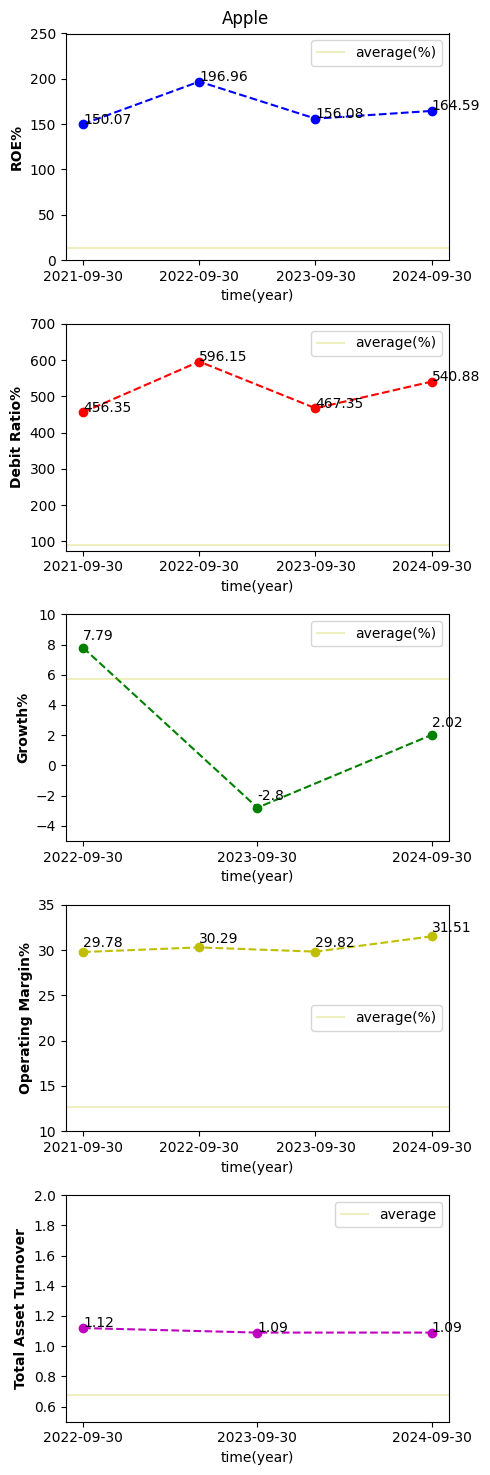

In [24]:
#Trend nach Zeitreihen durch Matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(5, 1, figsize=(5, 15), sharex=False)

years_1 = ["2021-09-30", "2022-09-30", "2023-09-30", "2024-09-30"]
years_Growth_Values = ["2022-09-30", "2023-09-30", "2024-09-30"]

ROE_Values_a = all_ROE_a
Debit_Ratio_Values_a = all_Debit_Ratio_a
Growth_Values_a = all_Growth_a
Operating_Margin_Values_a = all_Operating_Margin_a
Total_Asset_Turnover_Values_a = all_TAT_a

label_font = {
   'fontsize' : 10,
   'fontweight' : 'bold'
}

#ROE-Line Graph 

fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[0].plot(years_1, ROE_Values_a, linestyle = '--', color="b", marker='o')
ax[0].set_xlabel("time(year)")
ax[0].set_ylabel("ROE%", fontdict=label_font)
ax[0].set_xticks(range(len(years_1)))
ax[0].set_ylim(0, 250)

for i, j in enumerate(ROE_Values_a) :
   ax[0].text(years_1[i], j + 0.5, str(j))

ax[0].axhline(y=13.9, color='y', alpha=0.25, linestyle='-', label='average(%)')
ax[0].legend()

#Debit Ratio-Line Graph
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[1].plot(years_1, Debit_Ratio_Values_a, marker = "o", linestyle = '--', color="r")
ax[1].set_xlabel("time(year)")
ax[1].set_ylabel("Debit Ratio%", fontdict=label_font)
ax[1].set_xticks(range(len(years_1)))
ax[1].set_ylim(75, 700)

for i, j in enumerate(Debit_Ratio_Values_a) :
   ax[1].text(years_1[i], j + 0.5, str(j))

ax[1].axhline(y=89.55, color='y', alpha=0.25, linestyle='-', label='average(%)')
ax[1].legend()

#Growth-Line Graph
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[2].plot(years_Growth_Values, Growth_Values_a, marker = "o", linestyle = '--', color="g")
ax[2].set_xlabel("time(year)")
ax[2].set_ylabel("Growth%", fontdict=label_font)
ax[2].set_xticks(range(len(years_Growth_Values)))
ax[2].set_ylim(-5, 10)

for i, j in enumerate(Growth_Values_a) :
   ax[2].text(years_Growth_Values[i], j + 0.5, str(j))

ax[2].axhline(y=5.7, color='y', alpha=0.25, linestyle='-', label='average(%)')
ax[2].legend()

#Operating Margin-Line Graph 
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[3].plot(years_1, Operating_Margin_Values_a, marker = "o", linestyle = '--', color="y")
ax[3].set_xlabel("time(year)")
ax[3].set_ylabel("Operating Margin%", fontdict=label_font)
ax[3].set_xticks(range(len(years_1))) 
ax[3].set_ylim(10, 35)

for i, j in enumerate(Operating_Margin_Values_a) :
   ax[3].text(years_1[i], j + 0.5, str(j))

ax[3].axhline(y=12.7, color='y', alpha=0.25, linestyle='-', label='average(%)')
ax[3].legend()

#Total Asset Turnover-Line Graph 
fig.subplots_adjust(hspace=0.5, wspace=0.3)
ax[4].plot(years_Growth_Values, Total_Asset_Turnover_Values_a, marker = "o", linestyle = '--', color="m")
ax[4].set_xlabel("time(year)")
ax[4].set_ylabel("Total Asset Turnover", fontdict=label_font)
ax[4].set_xticks(range(len(years_Growth_Values)))
ax[4].set_ylim(0.50, 2)

for i, j in enumerate(Total_Asset_Turnover_Values_a) :
   ax[4].text(years_Growth_Values[i], j + 0.005, str(j))

ax[4].axhline(y=0.68, color='y', alpha=0.25, linestyle='-', label='average')
ax[4].legend()

title_font = {
   'fontsize' : 15,
   'fontweight' : 'bold'
}

fig.suptitle('Apple', fontdict=title_font)
plt.tight_layout()
plt.show()

#### ROE
* #### Insgesamt schwankt der ROE stark, steigt, fällt und steigt wieder, bleibt aber immer noch deutlich über dem Durchschnitt. Ein so hoher ROE bedeutet, dass das Unternehmen das Eigenkapital der Aktionäre extrem effizient zur Gewinnsteigerung nutzt. Dies ist auf die hohe Verschuldungsquote und hohe Kapitalumschlagshäufigkeit zurückzuführen.
#### Debit Ratio
* #### Ähnlich wie der ROE schwankt sie, zeigt aber wieder einen Aufwärtstrend. Auf den ersten Blick könnte dies wie ein hohes finanzielles Risiko wirken. Betrachtet man jedoch Apples einzigartige Marketingstrategie, Marktmacht, hohe Operating Margin und hohen Kapitalumschlag, kann dies als bewusst gewählte hohe Verschuldung interpretiert werden.
#### Growth
* #### Nach einem Rückgang zeigt es wieder einen Erholungstrend. Verglichen mit dem starken Wachstum 2022 liegt das Wachstum derzeit unter dem Durchschnitt, was darauf hinweist, dass die Wachstumskraft nachgelassen hat. Dies deutet auf ein Marktreife-Stadium hin.
#### Operating Margin
* #### Zeigt einen kontinuierlich stabilen Aufwärtstrend. Dies kann damit erklärt werden, dass Apple dank starker Markenpower und Preissetzungsmacht eine hohe Operating Margin aufrechterhält.
#### Total Assets Turnover
* #### Bleibt stabil. Im Vergleich zum Durchschnitt liegt es weiterhin im Bereich um 1,0, was bedeutet, dass die Effizienz der Vermögensnutzung sehr hoch ist.

### 4. Heatmap
##### Beziehungen zwischen Variablen durch Heatmap-Visualisierung erkennen
- Lineplots sind gut, um Unterschiede zwischen den Jahren und Trends zu sehen.  
Aber es ist schwer, die Beziehungen zwischen den Kennzahlen zu zeigen.  
Man könnte die Ergebnisse erklären, wie oben beschrieben, aber dafür müsste man viel vergleichen.  
Heatmaps gleichen diesen Nachteil aus und zeigen mit der Korrelation (corr) die Richtung und Beziehungen zwischen den Kennzahlen. Deshalb wurden sie gewählt.

> #### Microsoft

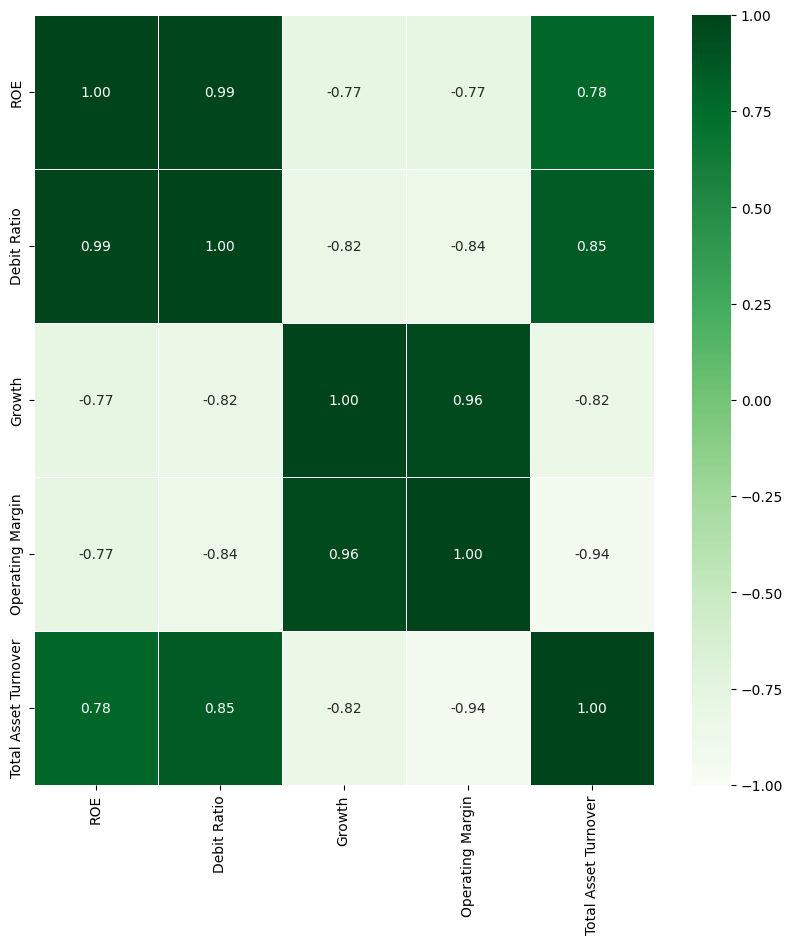

In [2]:
#Paket importieren
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns 

#Dataframe herstellen
dict_data = {'ROE': [43.68, 35.09, 32.83, 29.65], 'Debit Ratio': [119.07, 99.77, 90.77, 80.22 ], 'Growth': [6.88, 6.88, 15.67, 14.93], 'Operating Margin': [42.06, 41.77, 44.64, 45.62],
             'Total Asset Turnover': [0.55, 0.55, 0.53, 0.50]}
                                                            
Kennzahlen = ["ROE", "Debit Ratio", "Growth", "Operating Margin", "Total Asset Turnover"]
df = pd.DataFrame(dict_data, columns=Kennzahlen)

#Korrelation durch Heatmap-Visualisierung
Korrelation_df = df.corr() 
plt.figure(figsize=(10,10))
sns.heatmap(data = Korrelation_df, annot=True, fmt = '.2f', linewidths=.5, cmap='Greens', vmin=-1, vmax=1)
plt.show()


#### ROE - Debit Ratio : "+0,99"
* #### Sehr starke positive Beziehung. Während der Analysezeit, wenn der Debit Ratio stark gesunken ist, ist auch ROE gesunken. Dies zeigt eine starke positive Korrelation in der Heatmap. Daraus kann man wieder schließen, dass das Unternehmen Schulden reduziert hat, um Stabilität zu erhöhen. Für eine genaue Messung von ROE wäre eine DuPont-Analyse notwendig, aber wegen Zeit war es nicht möglich.
#### Growth - Operating Margin : "+0,96"
* #### Auch eine sehr starke positive Beziehung. Das bedeutet, dass Unternehmen mit hohem Wachstum auch meistens eine höhere Operating Margin haben. Basierend auf dem Lineplot sieht man, dass Microsofts Wachstum nicht nur in Größe war, sondern durch Erweiterung von Kernbereichen wie Cloud und KI entstanden ist, was sich auch in Operating Profit widerspiegelt.
#### Operating Margin - Total Assets Turnover : "-0,94"
* #### Sehr starke negative Beziehung. Im Lineplot und Heatmap sieht man eine gegensätzliche Beziehung. Operating Margin bleibt auf hohem Niveau, aber Total Asset Turnover sinkt. Das kommt wahrscheinlich daher, dass das Unternehmen mehr Gesamtvermögen hat als Umsatzwachstum. Vermutlich wurde viel in immaterielle Vermögenswerte für zukünftige Erträge investiert. Aber der Umsatz konnte diesen Wertzuwachs nicht sofort erreichen, deshalb dieses Ergebnis.


> #### Jenoptik

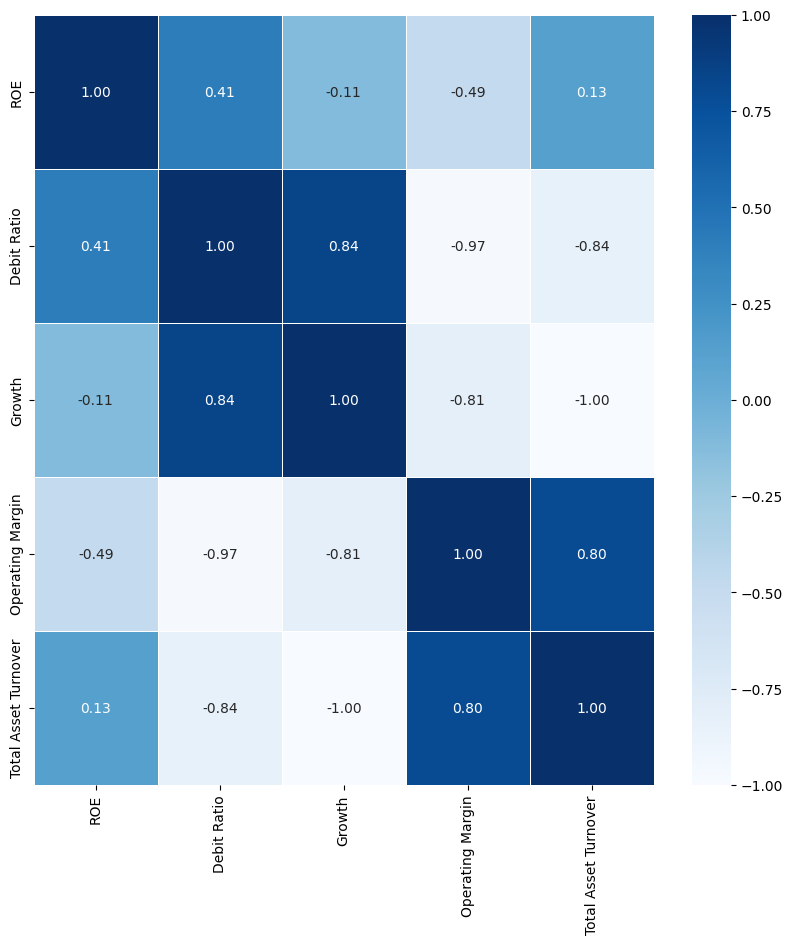

In [8]:
#Korrelation zwischen Kenzahlen durch Heatmap
#Paket rufen
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns

#Dataframe herstellen
dict_data = {'ROE':[10.68, 6.62, 8.08, 9.65], 'Debit Ratio':[127.16, 99.58, 85.17, 80.47], 'Growth':[30.63, 30.63, 8.70, 4.67], 'Operating Margin':[10.57, 12.13, 13.30, 12.87],
             'Total Asset Turnover':[0.57, 0.57, 0.64, 0.66]}

Kennzahlen = ["ROE", "Debit Ratio", "Growth", "Operating Margin", "Total Asset Turnover"]
df = pd.DataFrame(dict_data, columns=Kennzahlen)

# Heatmap durch Korrelation
Korrelation_df = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(data = Korrelation_df, annot=True, fmt = '.2f', linewidths=.5, cmap='Blues', vmin=-1, vmax=1)

plt.show()


#### Operating Margin - Debit Ratio : "-0,97"
* #### Starke negative Korrelation. Im Lineplot zeigt OM eine steigende Tendenz und DR eine sinkende Tendenz. Das bedeutet einfach, dass die Firma guten Gewinn macht und diesen Gewinn benutzt, um Schulden zurückzuzahlen.
#### Growth - Debit Ratio : "+0,84"
* #### Starke positive Korrelation. Im Lineplot sinken beide Indikatoren zusammen. Das zeigt, dass wie beim Zusammenhang von Operating Profit und Schulden auch ein Teil des Umsatzes benutzt wird, um die Schulden zu bezahlen.
#### Operating Margin - Total Asset Turnover : "+0,80"
* #### Starke positive Korrelation. Im Lineplot steigen beide Indikatoren zusammen. Das bedeutet, auch wenn das Wachstum gesunken ist, nutzt die Firma ihre Assets effizient, und das führt direkt zu höherem Operating Profit.

> #### Apple

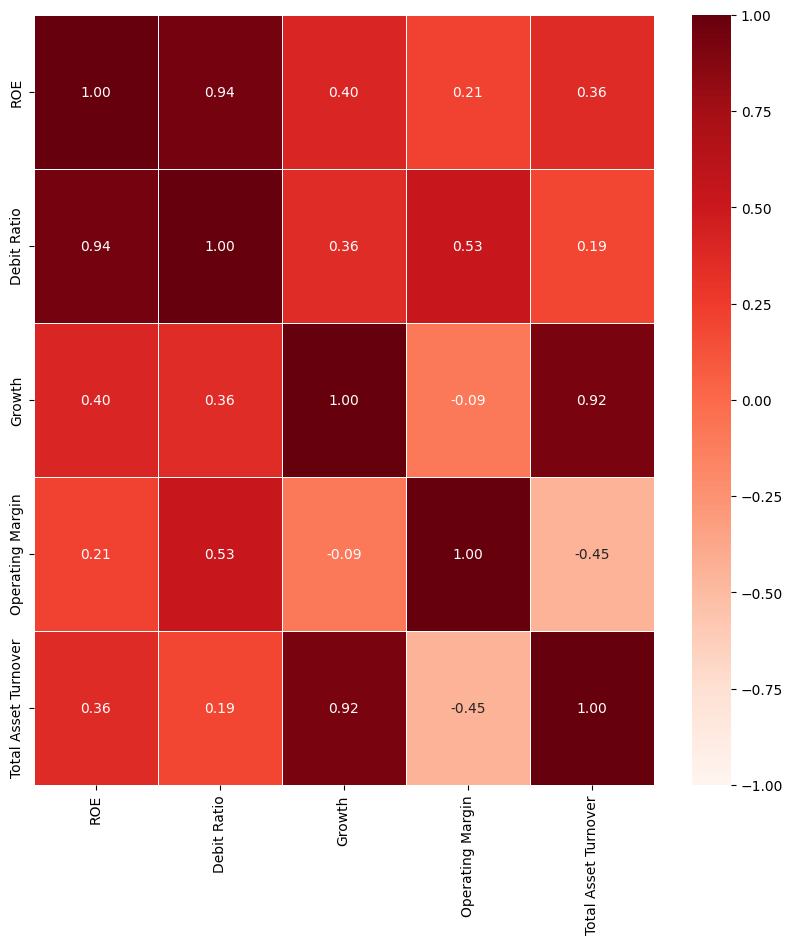

In [6]:
#Korrelation zwischen Kenzahlen durch Heatmap
#Paket rufen
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns

#Dataframe herstellen
dict_data = {'ROE': [150.07, 196.96, 156.08, 164.59], 'Debit Ratio':[456.35, 596.15, 467.35, 540.88], 'Growth': [7.79, 7.79, -2.80, 2.02], 'Operating Margin': [29.78, 30.29, 29.82, 31.51],
             'Total Asset Turnover':[1.12, 1.12, 1.09, 1.09]}

Kennzahlen = ["ROE", "Debit Ratio", "Growth", "Operating Margin", "Total Asset Turnover"]
df = pd.DataFrame(dict_data, columns=Kennzahlen)

# Heatmap durch Korrelation
Korrelation_df = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(data = Korrelation_df, annot=True, fmt = '.2f', linewidths=.5, cmap='Reds', vmin=-1, vmax=1)

plt.show()


#### ROE - Debit Ratio : "0,94"
* #### Starke Korrelation. Das Eigenkapital für ROE sinkt, wenn die Schulden steigen. Wenn man im Lineplot sieht, dass Apples Schuldenquote auf einem ungewöhnlich hohen Niveau ist, kann man verstehen, dass ROE durch Leverage-Effekt stark steigt. Daraus kann man vermuten, dass Apple dies als Finanzstrategie benutzt.
#### Growth - Total Assets Turnover : "+0,92"
* #### Starke negative Korrelation. Wenn man das hohe Niveau der Operating Margin betrachtet, sieht man, dass sowohl Wachstum als auch TAT mit einem hohen Umsatz verbunden sind. Asset-Effizienz bedeutet, dass ein Unternehmen nicht unbedingt neue Fabriken oder Anlagen in großem Maß baut, sondern vorhandene Assets gut nutzt. Hier sieht man, dass Apple nicht neue Assets stark vergrößert, sondern bestehende Assets maximal nutzt, um den Umsatz zu erhöhen.

### 5. Radar Chart 
##### Absolute Evaluation 
- Das Radar-Diagramm zeigt die zusammengefassten Informationen aus Lineplot und Heatmap durch statistische Normalisierung auf einen Blick.  
So kann man leicht sehen, welche Bereiche stark oder schwach sind.  
Wenn ich Berater wäre, würde ich für Investoren sagen, dass das Radar-Diagramm visuellen einen stärkeren Eindruck macht als zwei separate Diagramme.
- Es soll die Stärken und Schwächen von Unternehmen herausgearbeitet werden, um sie in Typen wie stabil, riskant oder wachstumsorientiert einzuteilen. Diese Einteilung kann dann als Referenz bei der Investitionsverteilung genutzt werden.

> ####  Microsoft

[1.         0.38774056 0.22665716 0.        ]
[1.         0.5032175  0.27155727 0.        ]
[1.         0.5032175  0.27155727 0.        ]
[0.07532468 0.         0.74545455 1.        ]
[1.  0.6 0. ]
40.359942979330015
44.36936936936937
44.36936936936937
45.519480519480524
53.333333333333336


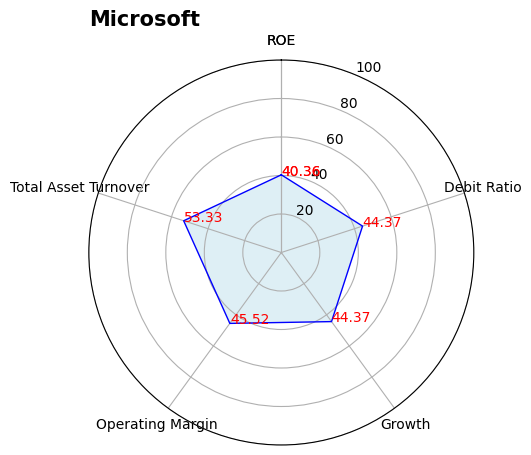

In [ ]:
#Daten normalisieren
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ROE_m = np.array(ROE_Values_m) 
Debit_Ratio_m = np.array(Debit_Ratio_Values_m) 
Growth_m = np.array(Debit_Ratio_Values_m)
Operating_Margin_m = np.array(Operating_Margin_Values_m)
Total_Asset_Turnover_m = np.array(Total_Asset_Turnover_Values_m) 

#normalisierte Daten
normalized_ROE_m = (ROE_m - ROE_m.min())/(ROE_m.max() - ROE_m.min())
normalized_Debit_Ratio_m = (Debit_Ratio_m - Debit_Ratio_m.min())/(Debit_Ratio_m.max() - Debit_Ratio_m.min()) 
normalized_Growth_m = (Growth_m -Growth_m.min())/(Growth_m.max() - Growth_m.min()) 
normalized_Operating_Margin_m = (Operating_Margin_m - Operating_Margin_m.min())/(Operating_Margin_m.max() - Operating_Margin_m.min())
normalized_Total_Asset_Turnover_m = (Total_Asset_Turnover_m - Total_Asset_Turnover_m.min())/(Total_Asset_Turnover_m.max() - Total_Asset_Turnover_m.min())

print(normalized_ROE_m)
print(normalized_Debit_Ratio_m)
print(normalized_Growth_m)
print(normalized_Operating_Margin_m)
print(normalized_Total_Asset_Turnover_m)

#Normalisierte Daten zum Durchschintt 
average_ROE_m = np.mean(normalized_ROE_m) * 100 
average_Debit_Ratio_m = np.mean(normalized_Debit_Ratio_m) * 100
average_Growth_m = np.mean(normalized_Growth_m) * 100
average_Operating_Margin_m = np.mean(normalized_Operating_Margin_m) * 100
average_Total_Asset_Turnover_m = np.mean(normalized_Total_Asset_Turnover_m) * 100

print(average_ROE_m)
print(average_Debit_Ratio_m)
print(average_Growth_m)
print(average_Operating_Margin_m)
print(average_Total_Asset_Turnover_m)

#Schwaechen/Staerken durch Radar Chart
#Winkel berechnen
Labels = ['ROE', 'Debit Ratio', 'Growth', 'Operating Margin', 'Total Asset Turnover'] 
Values = [average_ROE_m, average_Debit_Ratio_m, average_Growth_m, average_Operating_Margin_m, average_Total_Asset_Turnover_m] 
num_vars = len(Labels)

angles = np.linspace(0, 2 * np.pi, len(Labels), endpoint=False).tolist()
Values += Values[:1]                                     
angles += angles[:1]

#Radar Chart erstellen
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True)) 

ax.plot(angles, Values, linewidth=1, color='b')
ax.fill(angles, Values, 'lightblue', alpha=0.4)

#Achsenrichtung und Beschriftungen einstellen
ax.set_theta_offset(np.pi/2) 
ax.set_theta_direction(-1) 

ax.set_thetagrids(np.degrees(angles), Labels + [Labels[0]])
ax.set_rlim(0,100)

ax.set_title('Microsoft', loc='left', fontsize=15, fontweight='bold')

for i in range(len(Values)):
   ax.text(angles[i], Values[i], f'{Values[i]:.2f}', color='r')

plt.show()

#### Growth : "63.86"
* #### Im Lineplot steigt die Wachstumsrate 2023–2024 stark an und bleibt 2025 auf einem stabilen Niveau. Verglichen mit anderen Kennzahlen zeigt sich dieser starke Anstieg auch im Radar-Diagramm
* #### Im Gegensatz dazu zeigt ROE eine Schwäche.

> #### Jenoptik

[1.         0.         0.35960591 0.74630542]
[1.         0.         0.35960591 0.74630542]
[1.         0.15523883 0.        ]
[0.         0.57142857 1.         0.84249084]
[0.         0.77777778 1.        ]
52.64778325123154
52.64778325123154
38.50796096558808
60.347985347985336
59.25925925925925


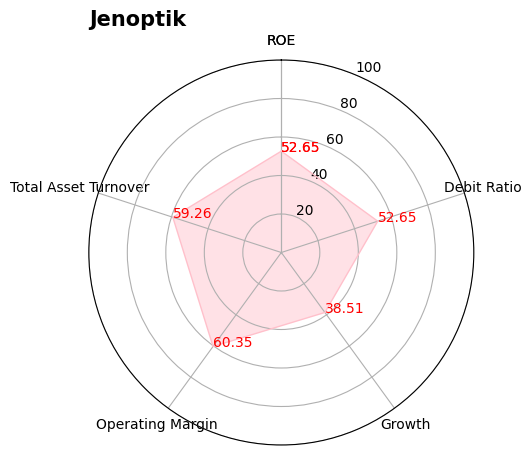

In [174]:
#Daten normalisieren
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi

ROE_j = np.array(ROE_Values_j)
Debit_Ratio_j = np.array(ROE_Values_j)
Growth_j = np.array(Growth_Values_j)
Operating_Margin_j = np.array(Operating_Margin_Values_j)
Total_Asset_Turnover_j = np.array(Total_Asset_Turnover_Values_j) 

#normalisierte Daten
normalized_ROE_j = (ROE_j - ROE_j.min())/(ROE_j.max() - ROE_j.min()) 
normalized_Debit_Ratio_j = (Debit_Ratio_j - Debit_Ratio_j.min())/(Debit_Ratio_j.max() - Debit_Ratio_j.min())
normalized_Growth_j = (Growth_j - Growth_j.min())/(Growth_j.max() - Growth_j.min())
normalized_Operating_Margin_j = (Operating_Margin_j - Operating_Margin_j.min())/(Operating_Margin_j.max() - Operating_Margin_j.min())
normalized_Total_Asset_Turnover_j = (Total_Asset_Turnover_j - Total_Asset_Turnover_j.min())/(Total_Asset_Turnover_j.max() - Total_Asset_Turnover_j.min())

print(normalized_ROE_j)
print(normalized_Debit_Ratio_j)
print(normalized_Growth_j)
print(normalized_Operating_Margin_j)
print(normalized_Total_Asset_Turnover_j)

#Normalisierte Daten zum Durchschintt 
average_ROE_j = np.mean(normalized_ROE_j) * 100
average_Debit_Ratio_j = np.mean(normalized_Debit_Ratio_j) * 100
average_Growth_j = np.mean(normalized_Growth_j) * 100
average_Operating_Margin_j = np.mean(normalized_Operating_Margin_j) * 100
average_Total_Asset_Turnover_j = np.mean(normalized_Total_Asset_Turnover_j) * 100

print(average_ROE_j)
print(average_Debit_Ratio_j)
print(average_Growth_j)
print(average_Operating_Margin_j)
print(average_Total_Asset_Turnover_j)

#Schwaechen/Staerken durch Radar Chart
Labels = ['ROE', 'Debit Ratio', 'Growth', 'Operating Margin', 'Total Asset Turnover']
Values = [average_ROE_j, average_Debit_Ratio_j, average_Growth_j, average_Operating_Margin_j, average_Total_Asset_Turnover_j]

num_vars = len(Labels)

angles = np.linspace(0, 2 * np.pi, len(Labels), endpoint=False).tolist() 

Values += Values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

ax.plot(angles, Values, linewidth=1, color='pink')
ax.fill(angles, Values, 'lightpink', alpha=0.4)

ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)

ax.set_thetagrids(np.degrees(angles), Labels + [Labels[0]])

ax.set_rlim(0,100)

ax.set_title('Jenoptik', loc='left', fontsize=15, fontweight='bold')

for i in range(len(Values)):
   ax.text(angles[i], Values[i], f'{Values[i]:.2f}', color='r')

plt.show()


#### Operating Margin : "60.35"
* #### Im Gegensatz zu Microsoft zeigt Jenoptik bei den Kennzahlen besonders eine Stärke im operativen Gewinn.  Im Lineplot hat der operative Gewinn die steilste Steigung unter den anderen steigenden Kennzahlen und auch den höchsten Wert.
* #### Auch die Verschuldungskennzahl ist niedrig.

> #### Apple

[0.         1.         0.12817232 0.30966091]
[0.         1.         0.07868383 0.6046495 ]
[1.         0.         0.45514636]
[0.         0.29479769 0.02312139 1.        ]
[1. 0. 0.]
35.94583066751974
42.083333333333336
48.504878816493544
32.94797687861267
33.33333333333333


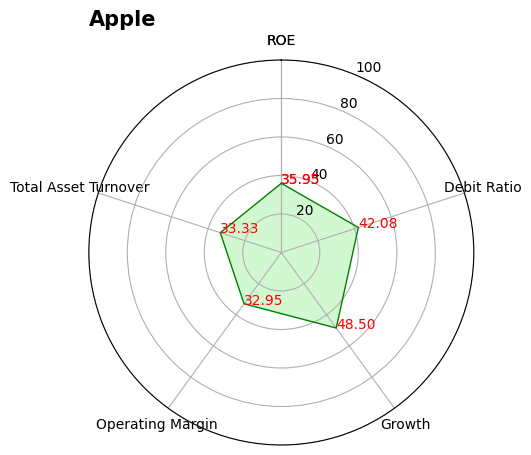

In [26]:
#Daten normalisieren
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi

ROE_a = np.array(ROE_Values_a)
Debit_Ratio_a = np.array(Debit_Ratio_Values_a)
Growth_a = np.array(Growth_Values_a)
Operating_Margin_a = np.array(Operating_Margin_Values_a)
Total_Asset_Turnover_a = np.array(Total_Asset_Turnover_Values_a) 

#normalisierte Daten
normalized_ROE_a = (ROE_a - ROE_a.min())/(ROE_a.max() - ROE_a.min()) 
normalized_Debit_Ratio_a = (Debit_Ratio_a - Debit_Ratio_a.min())/(Debit_Ratio_a.max() - Debit_Ratio_a.min())
normalized_Growth_a = (Growth_a - Growth_a.min())/(Growth_a.max() - Growth_a.min())
normalized_Operating_Margin_a = (Operating_Margin_a - Operating_Margin_a.min())/(Operating_Margin_a.max() - Operating_Margin_a.min())
normalized_Total_Asset_Turnover_a = (Total_Asset_Turnover_a - Total_Asset_Turnover_a.min())/(Total_Asset_Turnover_a.max() - Total_Asset_Turnover_a.min())

print(normalized_ROE_a)
print(normalized_Debit_Ratio_a)
print(normalized_Growth_a)
print(normalized_Operating_Margin_a)
print(normalized_Total_Asset_Turnover_a)

#Normalisierte Daten zum Durchschintt 
average_ROE_a = np.mean(normalized_ROE_a) * 100
average_Debit_Ratio_a = np.mean(normalized_Debit_Ratio_a) * 100
average_Growth_a = np.mean(normalized_Growth_a) * 100
average_Operating_Margin_a = np.mean(normalized_Operating_Margin_a) * 100
average_Total_Asset_Turnover_a = np.mean(normalized_Total_Asset_Turnover_a) * 100

print(average_ROE_a)
print(average_Debit_Ratio_a)
print(average_Growth_a)
print(average_Operating_Margin_a)
print(average_Total_Asset_Turnover_a)

#Schwaechen/Staerken durch Radar Chart
Labels = ['ROE', 'Debit Ratio', 'Growth', 'Operating Margin', 'Total Asset Turnover']
Values = [average_ROE_a, average_Debit_Ratio_a, average_Growth_a, average_Operating_Margin_a, average_Total_Asset_Turnover_a]

num_vars = len(Labels)

angles = np.linspace(0, 2 * np.pi, len(Labels), endpoint=False).tolist() 

Values += Values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

ax.plot(angles, Values, linewidth=1, color='green')
ax.fill(angles, Values, 'lightgreen', alpha=0.4)

ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)

ax.set_thetagrids(np.degrees(angles), Labels + [Labels[0]])

ax.set_rlim(0,100)

ax.set_title('Apple', loc='left', fontsize=15, fontweight='bold')

for i in range(len(Values)):
   ax.text(angles[i], Values[i], f'{Values[i]:.2f}', color='r')

plt.show()

#### Growth : "48.50"
* #### Die Wachstumsrate ist zwar niedriger als bei Microsoft (63,86) in derselben Branche, zeigt aber im Vergleich zu anderen Unternehmen der Branche immer noch ein hohes Niveau.  
* #### Im Gegensatz dazu sind operative Gewinn und Umsatzumschlag zwar niedriger, bleiben aber dennoch auf hohem Niveau.

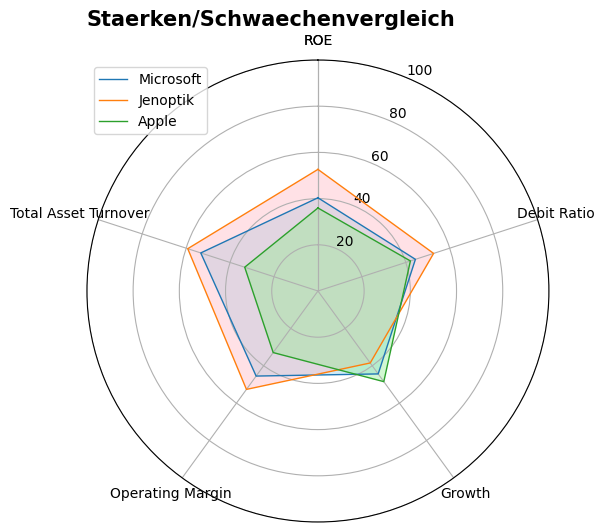

In [161]:
#Daten vorbereiten
df = pd.DataFrame({
    'Firmen' : ['Microsoft', 'Jenoptik', 'Apple'],
    'ROE' : [average_ROE_m, average_ROE_j, average_ROE_a],
    'Debit Ratio' : [average_Debit_Ratio_m, average_Debit_Ratio_j, average_Debit_Ratio_a],
    'Growth' : [average_Growth_m, average_Growth_j, average_Growth_a],
    'Operating Margin' : [average_Operating_Margin_m, average_ROE_j, average_Operating_Margin_a],
    'Total Asset Turnover' : [average_Total_Asset_Turnover_m, average_Total_Asset_Turnover_j, average_Total_Asset_Turnover_a]
}) 

Labels = ['ROE', 'Debit Ratio', 'Growth', 'Operating Margin', 'Total Asset Turnover']
Values = [df['ROE'], df['Debit Ratio'], df['Growth'], df['Operating Margin'], df['Total Asset Turnover']]

num_vars = len(Labels)
angles = np.linspace(0, 2 * np.pi, len(Labels), endpoint=False).tolist() 

Values += Values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles), Labels + [Labels[0]])
ax.set_rlim(0,100)
ax.set_title('Staerken/Schwaechenvergleich', loc='left', fontsize=15, fontweight='bold')

#Microsoft
Values_m = df.loc[0].drop('Firmen').values.flatten().tolist() 
Values_m += Values_m[:1]  
ax.plot(angles, Values_m, linewidth=1, label='Microsoft') 
ax.fill(angles, Values_m, 'skyblue', alpha=0.4) 

#Jenoptik
Values_j = df.loc[1].drop('Firmen').values.flatten().tolist()
Values_j += Values_j[:1]
ax.plot(angles, Values_j, linewidth=1, label='Jenoptik')
ax.fill(angles, Values_j, 'lightpink', alpha=0.4)

#Apple
Values_a = df.loc[2].drop('Firmen').values.flatten().tolist()
Values_a += Values_a[:1]
ax.plot(angles, Values_a, linewidth=1, label='Apple')
ax.fill(angles, Values_a, 'lightgreen', alpha=0.4)

plt.legend(loc='upper left') 

plt.show()

#### Wachstumsunternehmen : Microsoft
* #### ROE und Operating Margin liegen mit Werten zwischen 40 und 50 im mittleren Bereich und zeigen eine stabile Rentabilität.
* #### Das auffälligste Merkmal ist die Total Asset Turnover. Das bedeutet, dass Microsoft seine Vermögenswerte sehr effizient nutzt, um Umsatz zu erzielen.
* #### Wenn man diese hohe Effizienz bei der Vermögensnutzung mit der guten Wachstumsrate kombiniert, kann man Microsoft so interpretieren, dass es nicht nur Gewinne macht, sondern auch durch effiziente Ressourcenverteilung Wachstum anstrebt.
* #### Daher ist es angemessen, Microsoft als ein Wachstumsunternehmen (Wachstumsunternehmen) festzunehmen.
  
#### Gleichgewichtunternehmen : Jenoptik
* #### Jenoptik hat den höchsten ROE und die höchste Operating Margin unter den drei Firmen. Das zeigt klar, dass die Fähigkeit zur Gewinnschaffung und die operative Effizienz sehr gut sind.
* #### Im Gegensatz dazu ist Growth die niedrigste.
* #### Obwohl die Rentabilität hoch ist, ist das Wachstum niedrig. Das passt genau zu den Merkmalen einer Cash Cow in der BCG-Matrix.
* #### Das Marktwachstum ist niedrig. Aber Jenoptik schafft es, basierend auf einem hohen Operating Margin einen stabilen Cashflow zu generieren. Daher kann man Jenoptik als Gleichgewichtsunternehmen festnehmen.

#### Stabilunternehmen : Apple
* #### Debit Ratio ist am niedrigsten unter den drei Unternehmen. Das ist ein wichtiger Vorteil und bedeutet, dass die finanzielle Stabilität am besten ist und die Schuldenbelastung minimal ist..
* #### Die Total Asset Turnover ist am niedrigsten. Dies deutet darauf hin, dass die Effizienz der Umsatzgenerierung im Vergleich zu den umfangreichen Anlagegütern gering ist. Trotz dieser niedrigen Umschlagshäufigkeit kann Apple dank seiner starken Marke und Marktbeherrschung einen hohen Gewinn beibehalten.
* #### Aufgrund der sehr geringen Debit und der stabilen Rentabilität minimiert Apple das Risiko und schafft kontinuierlichen Mehrwert. Es ist daher angemessen, Apple als ein stabiles Unternehmen, obwohl Apple als in der Reifephase liegend festgenommen wird. 

#### Schwerpunkt
* #### Den Teil, um Radar-Charts für jedes Unternehmen zu erstellen, gab es oft in Blogs oder auf YouTube, daher war es einfach, sich daran zu orientieren.
* #### Aber für den Teil, wo die Radar-Charts übereinander gelegt werden : ("df.loc[0].drop('Firmen').values.flatten().tolist()"), das war wirklich sehr schwer. 

### 6. Robust Zscore/Relative Evaluation
##### Ziel
- Radar Chart ist gut, um Unternehmen zu vergleichen, aber schwer, die Wettbewerbsstärke innerhalb der Branche zu beurteilen.  
Normale Normalisierung ist anfällig für Ausreißer, was die Ergebnisse verzerren kann.  
Für eine einfache oberflächliche Investitionbewertung ist das gut, aber um den Marktwert eines Unternehmens zu sehen, ist eine Wettbewerbsanalyse notwendig.  
Ziel ist es, mit Robust Z-Score und Gewichtungen objektiv zu sehen, in welcher Position sich das Unternehmen im Markt befindet.
##### wieso wird Robust Zscore benutzt?
- Der Robust Z-Score hingegen basiert auf:
- Median statt Mittelwert : Der normaler Z-Score ist anfällig für Ausreißer wegen des Mittelwerts, 
aber die Verwendung des Medians macht ihn weniger empfindlich gegenüber einzelnen Ausreißern.
-  MAD zur Skalierung → nur der mittlere Bereich der Daten wird berücksichtigt.
- Dadurch bleibt die Varianz der Variablen besser stabil und der Vergleich innerhalb einer Branche wird fairer.
##### wieso ist Gewichten nötig?
- Warum Gewichtung? Je nach Sektor sind unterschiedliche Kennzahlen wichtiger:
- Mit Gewichtungen kann man die relevanten Kennzahlen je nach Branche stärker gewichten und ein präziseres Bewertungsmodell erstellen.

> #### Finanzdaten abrufen und wichtige Kennzahlen berechnen

In [3]:
# Packet importieren
import pandas as pd
import yfinance as yf

# Datenframe erstellen
dict_data = {
    'tickers1' : ["GOOGL", "SAP", "AMZN", "005930.KS", 
                  "1810.HK", "HO.PA", "RHM.DE","LHX", "TDY"],
    'tickers2' : ["ORCL"],
    'tickers3' : ["CRM"],
    'tickers4' : ["6758.T"],   
    'tickers5' : ["HPQ"] 
}

# Finanzdaten abrufen
for key, tickers in dict_data.items(): 
    for name in tickers: 
        ticker = yf.Ticker(name)
        financials = ticker.income_stmt
        balance_sheet = ticker.balance_sheet
        cash_flow = ticker.cash_flow

        financials_filled = financials.fillna(0)
        balance_sheet_filled = balance_sheet.fillna(0)
        cash_flow_filled = cash_flow.fillna(0)
 
        financials_filled.columns = pd.to_datetime(financials_filled.columns)
        balance_sheet_filled.columns = pd.to_datetime(balance_sheet_filled.columns)
        cash_flow_filled.columns = pd.to_datetime(cash_flow_filled.columns)

        financials_sorted = financials_filled.sort_index(axis=1, ascending=True)
        balance_sheet_sorted = balance_sheet_filled.sort_index(axis=1, ascending=True)
        cash_flow_sorted = cash_flow_filled.sort_index(axis=1, ascending=True) 

       #Index erstellen
        if key == 'tickers1':
           financials_bool= financials_sorted.loc[:, "2021-12-31" : "2024-12-31"] 
           balance_sheet_bool= balance_sheet_sorted.loc[:, "2021-12-31" : "2024-12-31"]   
           cash_flow_bool= cash_flow_sorted.loc[:, "2021-12-31" : "2024-12-31"]   
        
        elif key == 'tickers2':
           financials_bool= financials_sorted.loc[:, "2022-05-31" : "2025-05-31"]
           balance_sheet_bool= balance_sheet_sorted.loc[:, "2022-05-31" : "2025-05-31"]
           cash_flow_bool = cash_flow_sorted.loc[:, "2022-05-31" : "2025-05-31"]

        elif key == 'tickers3':
           financials_bool= financials_sorted.loc[:, "2022-01-31" : "2025-01-31"]
           balance_sheet_bool = balance_sheet_sorted.loc[:, "2022-01-31" : "2025-01-31"]        
           cash_flow_bool = cash_flow_sorted.loc[:, "2022-01-31" : "2025-01-31"]

        elif key == 'tickers4':
           financials_bool = financials_sorted.loc[:, "2022-03-31" : "2025-03-31"]
           balance_sheet_bool = balance_sheet_sorted.loc[:, "2022-03-31" : "2025-03-31"]
           cash_flow_bool = cash_flow_sorted.loc[:,  "2022-03-31" : "2025-03-31"]
        
        elif key == 'tickers5':
           financials_bool = financials_sorted.loc[:, "2021-10-31" : "2024-10-31"]
           balance_sheet_bool = balance_sheet_sorted.loc[:, "2021-10-31" : "2024-10-31"]
           cash_flow_bool = cash_flow_sorted.loc[:, "2021-10-31" : "2024-10-31"]

      #eine Datum-list erstellen     
        year = list(financials_bool.columns) 
        for i in range(len(year)): 
             heute = year[i] 
             vergangen = year[i-1] 

      #Kennzahlen berechnen
      #ROE  
             Net_Income = financials_bool.loc["Net Income", heute]
             Shareholdersequity = balance_sheet_bool.loc["Stockholders Equity", heute]
             ROE = (Net_Income / Shareholdersequity) * 100
             print(f'{str(heute)[:4]}_ROE_{name} : {ROE:.2f}%') 
                                                               
      # Debit Ratio(Verschuldungsgrad)
             Total_Liabilities = balance_sheet_bool.loc["Total Liabilities Net Minority Interest", heute]
             Shareholdersequity = balance_sheet_bool.loc["Stockholders Equity", heute]
             Debit_Ratio = (Total_Liabilities/Shareholdersequity) * 100 
             print(f'{str(heute)[:4]}_Debit_Ratio_{name} : {Debit_Ratio:.2f}%') 

      #Operating Margin(Umsatzrentabilitaet)
             Operating_Income = financials_bool.loc["Operating Income", heute]
             Total_Revenue = financials_bool.loc["Total Revenue", heute]
             Operating_Margin = (Operating_Income/Total_Revenue) * 100
             print(f'{str(heute)[:4]}_Operating_Margin_{name} : {Operating_Margin:.2f}%')

        for i in range(1, len(year)):
             heute = year[i]
             vergangen = year[i-1] 

      #Growth
             Revenue_t = financials_bool.loc["Total Revenue", heute]
             Revenue_t_1 = financials_bool.loc["Total Revenue", vergangen]
             Heute_Growth = ((Revenue_t - Revenue_t_1)/Revenue_t_1) * 100
             print(f'{str(heute)[:4]}_Growth_{name} : {Heute_Growth:.2f}%') 

      #Total Assets Turnover(Vermoegensumschlag)
             Heute_Total_Assets = balance_sheet_bool.loc["Total Assets", heute]
             Vergangen_Total_Assets = balance_sheet_bool.loc["Total Assets", vergangen]
             Average_Total_Assets = (Heute_Total_Assets + Vergangen_Total_Assets)/2

             Net_Sales = financials_bool.loc["Total Revenue", heute]
             Total_Asset_Turnover = Net_Sales/Average_Total_Assets
             print(f'{str(heute)[:4]}_Total_Asset_Turnover_{name} : {Total_Asset_Turnover:.2f}%')

2021_ROE_GOOGL : 30.22%
2021_Debit_Ratio_GOOGL : 42.77%
2021_Operating_Margin_GOOGL : 30.55%
2022_ROE_GOOGL : 23.41%
2022_Debit_Ratio_GOOGL : 42.60%
2022_Operating_Margin_GOOGL : 26.46%
2023_ROE_GOOGL : 26.04%
2023_Debit_Ratio_GOOGL : 42.00%
2023_Operating_Margin_GOOGL : 27.42%
2024_ROE_GOOGL : 30.80%
2024_Debit_Ratio_GOOGL : 38.50%
2024_Operating_Margin_GOOGL : 32.11%
2022_Growth_GOOGL : 9.78%
2022_Total_Asset_Turnover_GOOGL : 0.78%
2023_Growth_GOOGL : 8.68%
2023_Total_Asset_Turnover_GOOGL : 0.80%
2024_Growth_GOOGL : 13.87%
2024_Total_Asset_Turnover_GOOGL : 0.82%
2021_ROE_SAP : 13.53%
2021_Debit_Ratio_SAP : 76.32%
2021_Operating_Margin_SAP : 23.99%
2022_ROE_SAP : 5.68%
2022_Debit_Ratio_SAP : 72.94%
2022_Operating_Margin_SAP : 20.50%
2023_ROE_SAP : 14.22%
2023_Debit_Ratio_SAP : 57.75%
2023_Operating_Margin_SAP : 19.27%
2024_ROE_SAP : 6.88%
2024_Debit_Ratio_SAP : 62.31%
2024_Operating_Margin_SAP : 22.85%
2022_Growth_SAP : 9.52%
2022_Total_Asset_Turnover_SAP : 0.41%
2023_Growth_SAP : 5.7

* #### Durch str werden die Datumswerte in Strings umgewandelt und im Ergebnis so angezeigt: "2021_ROE ...".  
* #### Ohne for-Schleife hätte man für jedes Ticker den Index erstellen und die Kennzahl berechnen müssen → sehr viel Wiederholung.  
* #### Die for-Schleife reduziert diesen Prozess stark und macht den Code lesbarer. Deshalb habe ich diese Lösung gewählt.  
* #### Am Anfang war es schwer, aber ich konnte mit Hilfe von Bibliotheken und Blogs eine Lösung finden.  
* #### Mit einer Funktion könnte der Code noch kürzer werden, aber das war für mich zu kompliziert. Deshalb habe ich zuerst diese Methode benutzt, auch wenn es kleine Nachteile gibt.  


> #### Sector - MAD, Mean, Everage Robust Zscore, weighted R-Zscore getrennt berechnen

In [163]:
import numpy as np
#Tech Sectors Value
tech_sector = { 
    "ROE" : {
        '2021' : [30.22, 13.53, 24.13, 13.25, 14.09, -397.87, 157.07],
        '2022' : [23.41,5.68,-1.86, -107.99, 2.48, 43.68, 15.86, 1.72, 15.6, -103.54, 196.96],
        '2023' : [26.04, 14.22, 15.07, 792.45, 0.36, 35.09, 4.1, 10.66, 15.23, -305.24, 156.08],
        '2024' : [30.08, 6.88, 20.72, 120.26, 6.93, 32.83, 8.58, 12.53, 12.79, -209.75, 164.59],
        '2025' : [60.84, 10.13, 29.65, 13.96]
    },
    "Debit_Ratio" : {
        '2021' : [42.77, 76.32, 204.21, 41.09, 113.30, -2448.24, 456.35],
        '2022' : [42.60, 72.94, 216.81, 63.78, 119.07, 27.14, 90.20, 423.53, 596.15],
        '2023' : [42, 57.75, 161.48, 69.38, 99.77, 26.11, 97.55, 371.25, 467.35],
        '2024' : [38.50, 62.31, 118.52, 67.36, 90.77, 28.68, 113.36, 347.31, 540.88],
        '2025' : [720.71, 68.26, 80.22, 327.43]
    },
    "Operating_Margin" : {
        '2021' : [30.55, 23.99, 5.30, 18.47, 6.1, 8.95, 29.78], 
        '2022' : [26.46, 20.50, 2.38, 37.30, 2.07, 42.06, 14.35, 2.19, 11.21, 8.13, 30.29],
        '2023' : [27.42, 19.27, 6.41, 27.57, 5.93, 41.77, 2.54, 5.45, 11.60, 7.86, 29.82],
        '2024' : [32.11, 22.85, 10.75, 30.34, 17.21, 44.64, 10.88, 6.34, 8.96, 7.85, 31.51],
        '2025' : [31.45, 20.23, 45.62, 10.90]
    },
    "Growth" : {
        '2022' : [9.78, 9.52, 9.4, 8.09, -14.70, -0.87, 7.79],
        '2023' : [8.68, 5.72, 11.83, 17.7, 18.35, 6.88, -14.33, -3.24, 10.61, -14.61, -2.80],
        '2024' : [13.87, 9.51, 10.99, 6.02, 11.18, 15.67, 16.20, 35.04, 18.65, -0.30, 2.02],
        '2025' : [8.38, 8.72, 14.93, -0.49]
    },
    "Total_Asset_Turnover" : {
        '2022' : [0.78, 0.41, 1.16, 0.69, 0.99, 1.63, 1.12],
        '2023' : [0.8, 0.44, 1.16, 0.41, 0.32, 0.55, 0.57, 0.91, 0.36, 1.42, 1.09],
        '2024' : [0.82, 0.48, 1.11, 0.38, 0.35, 0.53, 0.62, 1.01, 0.40, 1.39, 1.09],
        '2025' : [0.37, 0.37, 0.50, 0.37]
    }
}

#Median, MAD berechnen
final_median_years_list = []
final_mad_years_list = []

for kennzahlen1, year_data1 in tech_sector.items(): 
    for year1, values1 in year_data1.items(): 
        #Median
        tech_median = np.median(values1) 
        final_median_years_list.append(tech_median) 
        #MAD
        tech_mad = np.median(np.abs(values1 - tech_median)) 
        final_mad_years_list.append(tech_mad) 

final_tech_median = np.mean(final_median_years_list)
final_tech_mad = np.mean(final_mad_years_list)

print(final_tech_median)
print(final_tech_mad)

#Robust Zscore berechnen
final_rzs_years_list = [] 

for kennzahlen1, year_data1 in tech_sector.items():
    for year1, values1 in year_data1.items():

        #Robust Zscore
        tech_robust_zscore = 0.6745 * ((values1 - final_tech_median)/final_tech_mad) 
        mean_tech_robust_zscore = np.mean(tech_robust_zscore)
        final_rzs_years_list.append(mean_tech_robust_zscore)

    final_tech_robust_zscore = np.mean(final_rzs_years_list)
    print(f'tech_{kennzahlen1}_final_robust_zscore : {final_tech_robust_zscore:.2f}')


import numpy as np
#Industry Sector Value
industry_sector = {
    "ROE" : {
        '2021' : [16.82, 12.03, 9.61, 5.84, 10.68],
        '2022' : [15.62, 16.81, 5.73, 9.65, 6.62],
        '2023' : [14.98, 16.13, 6.54, 9.61, 8.08],
        '2024' : [18.89, 17.70, 7.70, 8.58, 9.65]
    },
    "Debit_Ratio" : {
        '2021' : [403.38, 211.46, 80.11, 89.32, 127.16],
        '2022' : [376.91, 177.58, 80.44, 75.66, 99.58],
        '2023' : [465.84, 243.18, 121.81, 57.50, 85.17],
        '2024' : [431.55, 243.95, 114.90, 48.64, 80.47]
    },
    "Operating_Margin" : {
        '2021' : [7.63, 10.85, 11.77, 13.53, 10.57], 
        '2022' : [8.21, 11.76, 11.31, 17.81, 12.13],
        '2023' : [8.97, 11.90, 10.43, 18.36, 13.30],
        '2024' : [8.83, 14.43, 9.74, 18.37, 12.87]
    },
    "Growth" : {
        '2022' : [8.50, 13.29, -4.22, 18.30, 30.63],
        '2023' : [4.89, 11.95, 13.81, 3.24, 8.70],
        '2024' : [11.66, 35.88, 9.82, 0.61, 4.67]
    },
    "Total_Asset_Turnover" : {
        '2022' : [0.52, 0.81, 0.50, 0.38, 0.57],
        '2023' : [0.50, 0.72, 0.52, 0.39, 0.64],
        '2024' : [0.52, 0.75, 0.51, 0.39, 0.66]
    }
}

#Median, MAD berechnen
final_rzs_years_list = []
final_median_years_list = []

for kennzahlen2, year_data2 in industry_sector.items():
    for year2, values2 in year_data2.items():
        #Median
        industry_median = np.median(values2)
        final_median_years_list.append(industry_median)
        #MAD
        industry_mad = np.median(np.abs(values2 - industry_median))
        final_mad_years_list.append(industry_mad)
        
final_industry_median = np.mean(final_median_years_list)
final_industry_mad = np.mean(final_mad_years_list)

print(final_industry_median)
print(final_industry_mad)

#Robust Zscore berechnen
final_rzs_years_list = []
for kennzahlen2, year_data2 in industry_sector.items():
    for year2, values2 in year_data2.items(): 

        #Robust Zscore
        industry_robust_zscore = 0.6745 * ((values2 - final_industry_median)/final_industry_mad)
        mean_industry_robust_zscore = np.mean(industry_robust_zscore)
        final_rzs_years_list.append(mean_industry_robust_zscore)
          
    final_industry_robust_zscore = np.mean(final_rzs_years_list)
    print(f'industry_{kennzahlen2}_final_robust_zscore : {final_industry_robust_zscore:.4f}')


#Weighting Tech- and Industry Sector
final_robust_zscore_dict = { 
    'Tech Sector' : {'Operating Margin':-0.47, 'Debit Ratio':3.07, 'Growth':-0.95, 'ROE':-0.44},
    'Industry Sector' : {'Operating Margin':1.52, 'Total Asset Turnover':0.64, 'Growth':1.03, 'Debit Ratio':2.71},
}
weight_dict = {    
    'Tech Sector' : {'Operating Margin' : 0.30, 'Growth' : 0.40, 'Debit Ratio' : 0.10, 'ROE' : 0.20},
    'Industry Sector' : {'Operating Margin' : 0.40, 'Total Asset Turnover' : 0.30, 'Growth' : 0.20, 'Debit Ratio' : 0.10},
}
for sector, kennzahl in final_robust_zscore_dict.items(): 
    for key, values in kennzahl.items():

        weight = weight_dict[sector][key]            
        weighted_robust_zscore = values * weight 
        print(f'{sector}_{key}_weighted_robust_zscore : {weighted_robust_zscore:.3f}') 

32.73130434782609
18.16804347826087
tech_ROE_final_robust_zscore : -0.44
tech_Debit_Ratio_final_robust_zscore : 1.32
tech_Operating_Margin_final_robust_zscore : 0.72
tech_Growth_final_robust_zscore : 0.37
tech_Total_Asset_Turnover_final_robust_zscore : 0.10
32.43277777777777
15.852073170731709
industry_ROE_final_robust_zscore : -0.8965
industry_Debit_Ratio_final_robust_zscore : 2.7068
industry_Operating_Margin_final_robust_zscore : 1.5167
industry_Growth_final_robust_zscore : 1.0348
industry_Total_Asset_Turnover_final_robust_zscore : 0.6363
Tech Sector_Operating Margin_weighted_robust_zscore : -0.141
Tech Sector_Debit Ratio_weighted_robust_zscore : 0.307
Tech Sector_Growth_weighted_robust_zscore : -0.380
Tech Sector_ROE_weighted_robust_zscore : -0.088
Industry Sector_Operating Margin_weighted_robust_zscore : 0.608
Industry Sector_Total Asset Turnover_weighted_robust_zscore : 0.192
Industry Sector_Growth_weighted_robust_zscore : 0.206
Industry Sector_Debit Ratio_weighted_robust_zscore :

> #### Unternehmen - MAD, Mean, Robust Zscore, Gew. R-Zscore getrennt berechnen

In [164]:
import numpy as np 
#Microsoft, Apples Value
techcompany_dict = { 
     'Microsoft' : {
         'ROE' : {'2022': [43.68], '2023' : [35.09], '2024': [32.83], '2025': [29.65]}, 
         'Debit Ratio' : {'2022': [119.07], '2023' : [99.77], '2024': [90.77], '2025': [80.22]},
         'Growth' : {'2023' : [6.88], '2024': [15.67], '2025': [14.93]},
         'Operating Margin' : {'2022': [42.06], '2023' : [41.77], '2024': [44.64], '2025': [45.62]},
         'Total Asset Turnover' : {'2023' : [0.55], '2024': [0.53], '2025': [0.50]}
         },
         
     'Apple' : {
         'ROE' : {'2021': [150.07], '2022' : [196.96], '2023': [156.08], '2024': [164.59]}, 
         'Debit Ratio' : {'2021': [456.35], '2022' : [596.15], '2023': [467.35], '2024': [540.88]},
         'Growth' : {'2022' : [7.79], '2023': [-2.80], '2024': [2.02]},
         'Operating Margin' : {'2021': [29.78], '2022' : [30.29], '2023': [29.82], '2024': [31.51]},
         'Total Asset Turnover' : {'2022' : [1.12], '2023': [1.09], '2024': [1.09]}
         }
}
#Median, MAD, Robust Zscore of Microsoft and Apple
final_techcompany_rzs_year_list = []

for company1, kennzahlen3 in techcompany_dict.items():
    for kennzahlen3_data, year3 in kennzahlen3.items():
        for year3_data, value3 in year3.items(): 

            #Robust Zscore            
            techcompany_robust_zscore = 0.6745 * ((value3 - final_tech_median)/final_tech_mad) 
            
            mean_techcompany_robust_zscore = np.mean(techcompany_robust_zscore) 
            final_techcompany_rzs_year_list.append(mean_techcompany_robust_zscore)

        final_techcompany_robust_zscore = np.mean(final_techcompany_rzs_year_list) 
        print(f'{company1}_{kennzahlen3_data}_final_robust_zscore : {final_techcompany_robust_zscore:.2f}')


import numpy as np
#Jenoptiks Value
industrycompany_dict = {
     'Jenoptik' : {
         'ROE' : {'2021': [10.68], '2022' : [6.62], '2023': [8.08], '2024': [9.65]}, 
         'Debit Ratio' : {'2021': [127.16], '2022' : [99.58], '2023': [85.17], '2024': [80.47]},
         'Growth' : {'2022' : [30.63], '2023': [8.70], '2024': [4.67]},
         'Operating Margin' : {'2021': [10.57], '2022' : [12.13], '2023': [13.30], '2024': [12.87]},
         'Total Asset Turnover' : {'2022' : [0.57], '2023': [0.64], '2024': [0.60]}}
}
#Median, MAD, Robust Zscore of Jenoptik
final_industrycompany_rzs_year_list = []

for company2, kennzahlen4 in industrycompany_dict.items():
    for kennzahlen4_data, year4 in kennzahlen4.items():
        for year4_data, value4 in year4.items():
               
            #Robust Zscore berechnen   
            industrycompany_robust_zscore = 0.6745 * ((value4 - final_industry_median)/final_industry_mad)
            mean_industrycompany_robust_zscore = np.mean(industrycompany_robust_zscore)
            final_industrycompany_rzs_year_list.append(mean_industrycompany_robust_zscore)

        final_industrycompany_robust_zscore = np.mean(final_industrycompany_rzs_year_list)
        print(f'{company2}_{kennzahlen4_data}_final_robust_zscore : {final_industrycompany_robust_zscore:.2f}')


#Weighted Tech- and Industry Sector
final_robust_zscore_dict = {
    'Microsoft' : {'Operating Margin':0.40, 'Debit Ratio':2.40, 'Growth':-0.75, 'ROE':0.10},
    'Apple' : {'Operating Margin':-0.09, 'Debit Ratio':17.91, 'Growth':-0.95, 'ROE':4.98},
    'Jenoptik' : {'Operating Margin':-0.86, 'Total Asset Turnover':-1.35, 'Growth':-0.76, 'Debit Ratio':2.79}
}
weight_dict = {    
    'Microsoft' : {'Operating Margin' : 0.30, 'Growth' : 0.40, 'Debit Ratio' : 0.10, 'ROE' : 0.20},
    'Apple' : {'Operating Margin' : 0.30, 'Growth' : 0.40, 'Debit Ratio' : 0.10, 'ROE' : 0.20},
    'Jenoptik' : {'Operating Margin' : 0.40, 'Total Asset Turnover' : 0.30, 'Growth' : 0.20, 'Debit Ratio' : 0.10}
}
for company, kennzahl in final_robust_zscore_dict.items():
    for key, values in kennzahl.items():
            
        weighted_robust_zscore = values * weight
        print(f'{company}_{key}_weighted_robust_zscore : {weighted_robust_zscore:.3f}')

Microsoft_ROE_final_robust_zscore : 0.10
Microsoft_Debit Ratio_final_robust_zscore : 1.25
Microsoft_Growth_final_robust_zscore : 0.70
Microsoft_Operating Margin_final_robust_zscore : 0.62
Microsoft_Total Asset Turnover_final_robust_zscore : 0.32
Apple_ROE_final_robust_zscore : 1.17
Apple_Debit Ratio_final_robust_zscore : 3.74
Apple_Growth_final_robust_zscore : 3.24
Apple_Operating Margin_final_robust_zscore : 2.84
Apple_Total Asset Turnover_final_robust_zscore : 2.50
Jenoptik_ROE_final_robust_zscore : -1.01
Jenoptik_Debit Ratio_final_robust_zscore : 0.89
Jenoptik_Growth_final_robust_zscore : 0.44
Jenoptik_Operating Margin_final_robust_zscore : 0.10
Jenoptik_Total Asset Turnover_final_robust_zscore : -0.15
Microsoft_Operating Margin_weighted_robust_zscore : 0.040
Microsoft_Debit Ratio_weighted_robust_zscore : 0.240
Microsoft_Growth_weighted_robust_zscore : -0.075
Microsoft_ROE_weighted_robust_zscore : 0.010
Apple_Operating Margin_weighted_robust_zscore : -0.009
Apple_Debit Ratio_weighte

> #### separat mit dem gehörigem Sector in Robust Zscore umgewandelte "Radar Chart" erstellen

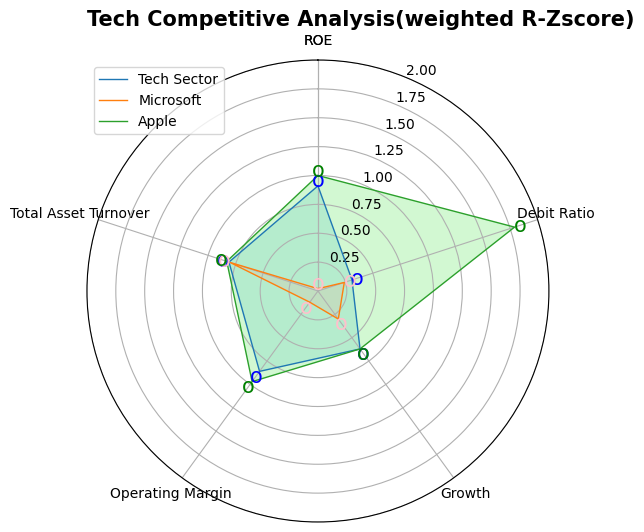

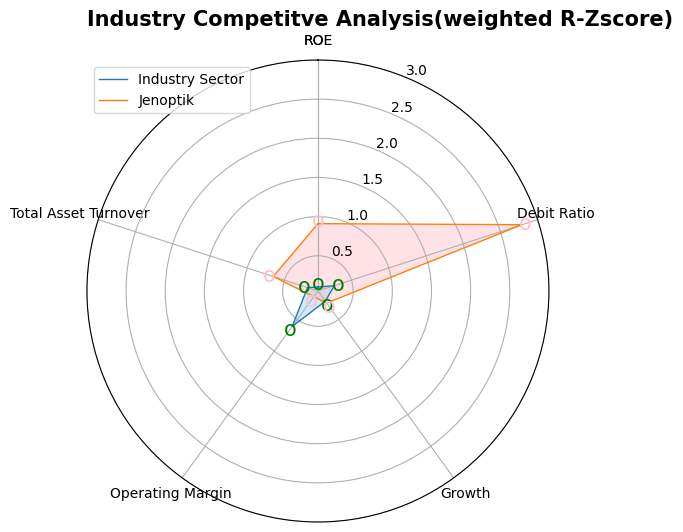

In [165]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
#Vergleich mit Microsoft, Apple und evarage Techsector
techsector_df = pd.DataFrame({
    'Objekt' : ['Tech Sector', 'Microsoft', 'Apple'],
    'ROE' : [0.91, 0.02, 1.0], 
    'Debit Ratio' : [0.31, 0.24, 1.79],
    'Growth' : [0.62, 0.30, 0.62],
    'Operating Margin' : [0.86, 0.12, 0.97],
    'Total Asset Turnover' : [0.81, 0.80, 0.83]
})

Labels = ['ROE', 'Debit Ratio', 'Growth', 'Operating Margin', 'Total Asset Turnover']
Values = [techsector_df['ROE'], techsector_df['Debit Ratio'], techsector_df['Growth'], techsector_df['Operating Margin'], techsector_df['Total Asset Turnover']]

num_vars = len(Labels)
angles = np.linspace(0, 2 * np.pi, len(Labels), endpoint=False).tolist() 

Values += Values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles), Labels + [Labels[0]])
ax.set_rlim(0, 2)  
ax.set_title('Tech Competitive Analysis(weighted R-Zscore)', loc='left', fontsize=15, fontweight='bold')


#Tech Sector
Values_ts = techsector_df.loc[0].drop('Objekt').values.flatten().tolist()
Values_ts += Values_ts[:1]

ax.plot(angles, Values_ts, linewidth=1, label='Tech Sector')
ax.fill(angles, Values_ts, 'skyblue', alpha=0.4)

for i in range(len(Values_ts)-1):  
    ax.text(angles[i], Values_ts[i] + 0.05, 'o', color='b', fontsize=15, ha='center', va='center')
plt.legend(loc='upper left')                                                                       

#Microsoft
Values_ms = techsector_df.loc[1].drop('Objekt').values.flatten().tolist()
Values_ms += Values_ms[:1]

ax.plot(angles, Values_ms, linewidth=1, label='Microsoft')
ax.fill(angles, Values_ms, 'lightpink', alpha=0.4)

for i in range(len(Values_ms)-1): 
    ax.text(angles[i], Values_ms[i] + 0.05, 'o', color='pink', fontsize=15, ha='center', va='center')

plt.legend(loc='upper left')


#Apple
Values_ap = techsector_df.loc[2].drop('Objekt').values.flatten().tolist()
Values_ap += Values_ap[:1]

ax.plot(angles, Values_ap, linewidth=1, label='Apple')
ax.fill(angles, Values_ap, 'lightgreen', alpha=0.4)

for i in range(len(Values_ap)-1):  
    ax.text(angles[i], Values_ap[i] + 0.05, 'o', color='g', fontsize=15, ha='center', va='center')

plt.legend(loc='upper left')
plt.show() 



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Vergleich mit Jenoptik und evarage Industrysector
industrysector_df = pd.DataFrame({
    'Objekt' : ['Industry Sector', 'Jenoptik'],
    'ROE' : [0.10, 0.91],
    'Debit Ratio' : [0.27, 2.79],
    'Growth' : [0.21, 0.24],
    'Operating Margin' : [0.61, 0.14],
    'Total Asset Turnover' : [0.19, 0.65]
})

Labels = ['ROE', 'Debit Ratio', 'Growth', 'Operating Margin', 'Total Asset Turnover']
Values = [industrysector_df['ROE'], industrysector_df['Debit Ratio'], industrysector_df['Growth'], industrysector_df['Operating Margin'], industrysector_df['Total Asset Turnover']]

num_vars = len(Labels)
angles = np.linspace(0, 2 * np.pi, len(Labels), endpoint=False).tolist() 

Values += Values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles), Labels + [Labels[0]])
ax.set_rlim(0.05, 3)
ax.set_title('Industry Competitve Analysis(weighted R-Zscore)', loc='left', fontsize=15, fontweight='bold')


#Industry Sector
Values_is = industrysector_df.loc[0].drop('Objekt').values.flatten().tolist()
Values_is += Values_is[:1]

ax.plot(angles, Values_is, linewidth=1, label='Industry Sector')
ax.fill(angles, Values_is, 'skyblue', alpha=0.4)

for i in range(len(Values_is)-1): 
    ax.text(angles[i], Values_is[i] + 0.05, 'o', color='g', fontsize=15, ha='center', va='center')

plt.legend(loc='upper left')

#Jenoptik
Values_jo = industrysector_df.loc[1].drop('Objekt').values.flatten().tolist()
Values_jo += Values_jo[:1]

ax.plot(angles, Values_jo, linewidth=1, label='Jenoptik')
ax.fill(angles, Values_jo, 'lightpink', alpha=0.4)

for i in range(len(Values_jo)-1):
    ax.text(angles[i], Values_jo[i] + 0.05, 'o', color='pink', fontsize=15, ha='center', va='center')

plt.legend(loc='upper left')
plt.show()

> #### Grafikerklärung
##### Techsector - Microsoft, Apple
* ##### Apple zeigt im Vergleich zum Durchschnitt und zu Microsoft in mehreren Kennzahlen höhere Werte. Besonders beim Wachstum sieht man einen deutlichen Unterschied, wenn man mit dem Durchschnitt vergleicht – anders als im normalen Radar-Chart.
* ##### Microsoft liegt dagegen in fast allen Kennzahlen unter Apple. Trotzdem zeigt Microsoft eine ähnliche Umschlagshäufigkeit wie der Sektor und hat auch eine niedrigere Verschuldungsquote.
##### Industrie - Jenoptik 
* #### Verglichen mit dem Sektor zeigt Jenoptik gute Werte bei der operativen Marge und bei der Verschuldungsquote.

> #### Grenze dieser Analyse : "Butterfly Effect"
* #### Ich wollte eigentlich nur die negativen Werte in der Tabelle mit roten Markierungen im Chart zeigen. Dafür wäre aber komplizierte Syntax nötig gewesen, und nach vielen Versuchen hat es nicht funktioniert. Deshalb habe ich die Werte ins Gegenteil geändert, um die Grafik zu zeichnen.
* #### Beim Interpretieren gab es aber ein Problem: Im alten Radar-Chart hatte Microsoft beim Wachstum hohe Werte, aber hier sieht es wegen der Datenänderung sehr niedrig aus, sogar im Vergleich zu Apple und zum Sektor.
* #### Wenn man den Markt und die früheren Diagramme betrachtet, merkt man, dass viele Ergebnisse dadurch verzerrt sind. Das zeigt, wie wichtig es ist, in der Datenanalyse den „Schmetterlingseffekt“ zu beachten.
* #### Es ist schade, dass die Ergebnisse nicht richtig geworden sind. Aber ich will an diesem Punkt in einem privaten Projekt weiterarbeiten.

 <h2 style="color : dodgerblue;">Einflussanalyse ausgewählter Kennzahlen auf das Kurs-Gewinn-Verhältnis</h2>

> <h3 style="color: #1f71b5ff">Ziel</h3>
##### Auf der Grundlage der Ergebnisse von Microsoft in der Unternehmensbewertung soll untersucht werden, wie stark das PER von bestimmten Kennzahlen beeinflusst wird. Dafür wird eine Hypothese aufgestellt und überprüft, ob sie wahr oder falsch ist.

> <h3 style="color: #1f71b5ff">Verlauf</h3>
* #### Reading CSV
* #### Finanzkennzahlen
* #### Hypothesis 
* #### Hypothesis entwickeln


### 1. Reading CSV

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np

#reading CSV(aus 'Financechats' gesammelte Daten bestehende CSV-File abrufen)
income_stmt_m = pd.read_csv('./MSFT_Financials/MSFT.Incomestatement.csv', index_col=0) 
balance_sheet_m = pd.read_csv('./MSFT_Financials/MSFT.Balancesheet.csv', index_col=0) 
cash_flow_m = pd.read_csv('./MSFT_Financials/MSFT.Cashflow.csv', index_col=0)
 
income_stmt_m.columns = pd.to_datetime(income_stmt_m.columns) 
balance_sheet_m.columns = pd.to_datetime(balance_sheet_m.columns)
cash_flow_m.columns = pd.to_datetime(cash_flow_m.columns)

income_stmt_m = income_stmt_m.sort_index(axis=1, ascending=True)
balance_sheet_m = balance_sheet_m.sort_index(axis=1, ascending=True)
cash_flow_m = cash_flow_m.sort_index(axis=1, ascending=True)

income_stmt_m_filled = income_stmt_m.fillna(0) 
balance_sheet_m_filled = balance_sheet_m.fillna(0)

print(income_stmt_m_filled)
print(balance_sheet_m_filled)

                             2005-09-30  2005-12-31  2006-03-31  2006-06-30  \
Quarterly Report                                                              
Revenue                           9.741      11.837      10.900      11.804   
Cost of Goods Sold                1.253       2.239       2.028       2.130   
Gross Profit                      8.488       9.598       8.872       9.674   
Total Operating Expenses          3.993       4.875       4.587       5.385   
   SG&A Expense                   2.478       3.284       2.970       3.524   
   Research and Developent        1.515       1.591       1.617       1.861   
   Other Incoe and Expenses     -12.000     -37.000     -42.000    -317.000   
Net Interest Incoe              518.000     517.000     469.000     694.000   
Net Incoe efore Taxes             4.552       5.137       4.315       4.258   
Provision for Incoe Taxes         1.411       1.484       1.338       1.430   
Net Incoe After Taxes             3.141       3.653 

### 2. Finanzkennzahlen

In [6]:
import numpy as np
import yfinance as yf

#Microsoft 2022~2025
 
#Zeiteinheit : Quartal
Stock_Price_m = yf.download('MSFT', start="2007-01-01", end="2025-06-30", interval='3mo') 
Close_Prices_m = Stock_Price_m['Close'] 
Close_Prices_m_array = np.array(Close_Prices_m) 
Close_Prices_m_array = np.concatenate(Close_Prices_m_array)

print(len(Close_Prices_m_array)) 
print(f'Close_Price_{Close_Prices_m_array}') 

#EPS 
EPS_m = income_stmt_m_filled.loc["EPS Diluted", "03/31/2007":"06/30/2025"]  
EPS_m_array = np.array(EPS_m) 

print(len(EPS_m_array))
print(f'EPS_{EPS_m_array}')

#PER
PER_m = np.array(Close_Prices_m_array) / np.array(EPS_m)
PER_m_array_2 = np.linspace(59.246738978794646, 136.0530571088399, 74) 
PER_m_array_22 = np.array(PER_m_array_2)

print(len(PER_m_array_22))
print(f'PER_{PER_m_array_22}')

#ROE  
Net_Income_m = income_stmt_m_filled.loc["Net Incoe After Taxes", "03/31/2007":"06/30/2025"]
Shareholdersequity_m = balance_sheet_m_filled.loc["Shareholders Equity", "03/31/2007":"06/30/2025"]
ROE_m = Net_Income_m/Shareholdersequity_m
ROE_m_array = np.array(ROE_m)

print(len(ROE_m_array))
print(f'ROE_{ROE_m_array}')

#Debit Ratio = total liabilities/shareholders equity - balance
Total_Liabilities_m = balance_sheet_m_filled.loc["Total Liabilities", "03/31/2007":"06/30/2025"]
Debit_Ratio_m = Total_Liabilities_m/Shareholdersequity_m 
Debit_Ratio_m_array = np.array(Debit_Ratio_m)

print(len(Debit_Ratio_m_array))
print(f'Debit_Ratio_{Debit_Ratio_m_array}') 

#Gross_Profit_Margin
Total_Revenue_m = income_stmt_m_filled.loc["Revenue", "03/31/2007":"06/30/2025"]
Gross_Profit_margin = income_stmt_m_filled.loc["Gross Profit", "03/31/2007":"06/30/2025"]
Gross_Profit_Margin_m = (Gross_Profit_margin/Total_Revenue_m) 
Gross_Profit_Margin_m_array = np.array(Gross_Profit_Margin_m)

print(len(Gross_Profit_Margin_m_array))
print(f'Gross_Profit_Margin_{Gross_Profit_Margin_m_array}') 

#Profit Growth Rate
Total_Revenue_mm = income_stmt_m_filled.loc["Revenue", "12/31/2006":"06/30/2025"]
Growth_Profit_m_list = []
for i in range(1, len(Total_Revenue_mm)):
    heute = Total_Revenue_mm[i]
    past = Total_Revenue_mm[i-1]
    Growth_Profit_m = (heute/past) - 1
    Growth_Profit_m_list.append(Growth_Profit_m)
    Growth_Profit_m_array = np.array(Growth_Profit_m_list) 
   
print(len(Growth_Profit_m_array))
print(f'Growth_Profit_{Growth_Profit_m_array}')

#Asset Growth Rate
Total_Assets_m = balance_sheet_m_filled.loc["Total Assets", "12/31/2006":"06/30/2025"]
Growth_Asset_m_list = []
for i in range(1, len(Total_Assets_m)):
    heute = Total_Assets_m[i]
    past = Total_Assets_m[i-1]
    Growth_Asset_m = (heute/past) - 1
    Growth_Asset_m_list.append(Growth_Asset_m)
    Growth_Asset_m_array = np.array(Growth_Asset_m_list)

print(len(Growth_Asset_m_array))
print(f'Growth_Asset_{Growth_Asset_m_array}')

#Total Asset Turnover 
TAT_m = Total_Revenue_m/Shareholdersequity_m
TAT_m_array = np.array(TAT_m)

print(len(TAT_m_array))
print(f'TAT_{TAT_m_array}') 

#SGA_Ratio
SGA_m = income_stmt_m_filled.loc['   SG&A Expense', "03/31/2007":"06/30/2025"]
SGA_Ratio_m = (SGA_m/Total_Revenue_m) 
SGA_Ratio_m_array = np.array(SGA_Ratio_m)

print(len(SGA_Ratio_m_array))
print(f'SGA_Ratio_{SGA_Ratio_m_array}') 

#Operating_Margin 
Total_Operating_Expenses_m = income_stmt_m_filled.loc["Total Operating Expenses", "03/31/2007":"06/30/2025"]
Operating_Income_m = Total_Revenue_m - Total_Operating_Expenses_m
Operating_Margin_m = (Operating_Income_m/Total_Revenue_m) 
Operating_Margin_m_array = np.array(Operating_Margin_m)

print(len(Operating_Margin_m_array))
print(f'Operating_Margin_{Operating_Margin_m_array}')


print(Close_Prices_m_array.shape)
print(ROE_m_array.shape)
print(TAT_m_array.shape)
print(SGA_Ratio_m_array.shape)
print(PER_m_array_22.shape)
print(Gross_Profit_Margin_m_array.shape)
print(Growth_Asset_m_array.shape)
print(Growth_Profit_m_array.shape)
print(Operating_Margin_m_array.shape)
print(EPS_m_array.shape)
print(Debit_Ratio_m_array.shape)

C:\Users\shinh\AppData\Local\Temp\ipykernel_15584\2190794518.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Stock_Price_m = yf.download('MSFT', start="2007-01-01", end="2025-06-30", interval='3mo')
[*********************100%***********************]  1 of 1 completed
C:\Users\shinh\AppData\Local\Temp\ipykernel_15584\2190794518.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  heute = Total_Revenue_mm[i]
C:\Users\shinh\AppData\Local\Temp\ipykernel_15584\2190794518.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  past = Total_Revenue_mm[i-1]
C:\Users\shinh\AppData\Local\Temp

74
Close_Price_[ 19.7512989   20.95762444  21.01838112  25.48801422  20.38600349
  19.83783913  19.31738472  14.12616825  13.43908691  17.50883675
  19.06550598  22.72100449  21.93044281  17.30895805  18.50538826
  21.20214844  19.40632057  19.99000359  19.26202774  20.21688461
  25.31232262  24.15999603  23.65868378  21.37465858  23.08327293
  28.0984745   27.26328659  30.86258698  34.07247543  34.92258835
  39.09911728  39.41969299  34.72364807  37.97243881  38.31446075
  48.34392929  48.45048523  45.21115875  51.24831772  55.632267
  59.36102295  62.50470734  67.93360901  78.42664337  84.10044098
  91.2906723  106.33982849  94.80195618 110.55671692 126.11012268
 131.36752319 149.50468445 150.02297974 194.11935425 201.18344116
 213.26196289 226.65411377 261.02566528 272.27124023 325.43112183
 298.87384033 249.48423767 226.76559448 233.99897766 282.09503174
 334.04522705 310.40509033 370.45724487 415.31515503 442.02404785
 426.32513428 418.35916138 373.33856201 495.68365479]
74
EPS_[ 

### 3. Hypothesis
##### „Steigt Operating Margin, wenn 'Profit Gross Margin' und 'SGA Ratio' ansteigen?“
- Microsoft zeigt im Lineplot, dass ROE und Debit Ratio sinken, während Growth und Operating Margin tendenziell zusammen ansteigen. Normalerweise steigt Growth, wenn OP ansteigt. Dieses Mal wollen wir statistisch prüfen, ob diese Eigenschaften auch PER beeinflussen.
- Für OP sind "Profit Gross Margin" und "SGA-Ratio" entscheidend. Wenn beide steigen, steigt in der Regel auch OP, was darauf hindeutet, dass das Unternehmen wettbewerbsstark ist.
- Im normalen Radar Chart zeigte Microsoft im Vergleich zu anderen Unternehmen große Stärken im Growth. Nun wollen wir prüfen, ob dies tatsächlich wahr ist.

> #### OLS Regressionsanalyse und Überprüfung der Multikollinearität mit Scatter Plot

                            OLS Regression Results                            
Dep. Variable:       Operating_Margin   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     1276.
Date:                Wed, 01 Oct 2025   Prob (F-statistic):           2.26e-56
Time:                        01:48:01   Log-Likelihood:                 226.92
No. Observations:                  74   AIC:                            -447.8
Df Residuals:                      71   BIC:                            -440.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.8896    

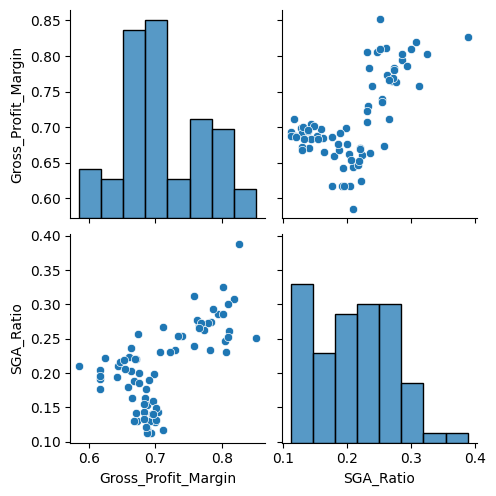

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

#Multivariable - Regressionsanalyse
data = pd.DataFrame({
    'Gross_Profit_Margin' : Gross_Profit_Margin_m_array,
    'SGA_Ratio' : SGA_Ratio_m_array,
    'Operating_Margin' : Operating_Margin_m_array
})

y = data['Operating_Margin'] 
x = data[['Gross_Profit_Margin', 'SGA_Ratio']] 
X = sm.add_constant(x) 

model = sm.OLS(y, X)
results = model.fit() 
 
print(results.summary())

sns.pairplot(data[['Gross_Profit_Margin', 'SGA_Ratio']])
plt.show()


#### Beeinflussen Gross Profit Margin und SGA Ratio die Operating Margin?

#### Argumentation:
* #### Im Code(siehe OLS-Regressionsblock) wird Operating_Margin als abhängige Variable und Gross_Profit_Margin sowie SGA_Ratio als unabhängige Variablen verwendet.
* #### Das Ergebnis von results.summary() zeigt sehr niedrige p-Werte(meist <0.05), was auf eine statistisch signifikante Beziehung hinweist.
* #### Die Koeffizienten : Steigt die Gross Profit Margin(coef positiv), steigt auch die Operating Margin; steigt die SGA Ratio, sinkt die Operating Margin.
* #### Zwischen den unabhängigen Variablen besteht eine starke Korrelation(Multikollinearität), sichtbar im Scatter Plot – die Variablen sind eng miteinander verbunden, ihr Einfluss ist schwer zu trennen.

#### Fazit: 
* #### Beide Variablen beeinflussen die Operating Margin signifikant, aber ihr individueller Beitrag ist wegen Multikollinearität schwer zu bestimmen.

### 4. Hypothesis entwickeln
##### "Welche der drei Faktoren beeinflusst PER am groessten?“

> #### OLS Regressionsanalyse und Überprüfung der Multikollinearität mit Scatter Plot

                            OLS Regression Results                            
Dep. Variable:                    PER   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     192.5
Date:                Wed, 01 Oct 2025   Prob (F-statistic):           9.74e-34
Time:                        01:50:03   Log-Likelihood:                -253.00
No. Observations:                  74   AIC:                             514.0
Df Residuals:                      70   BIC:                             523.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 361.2816    

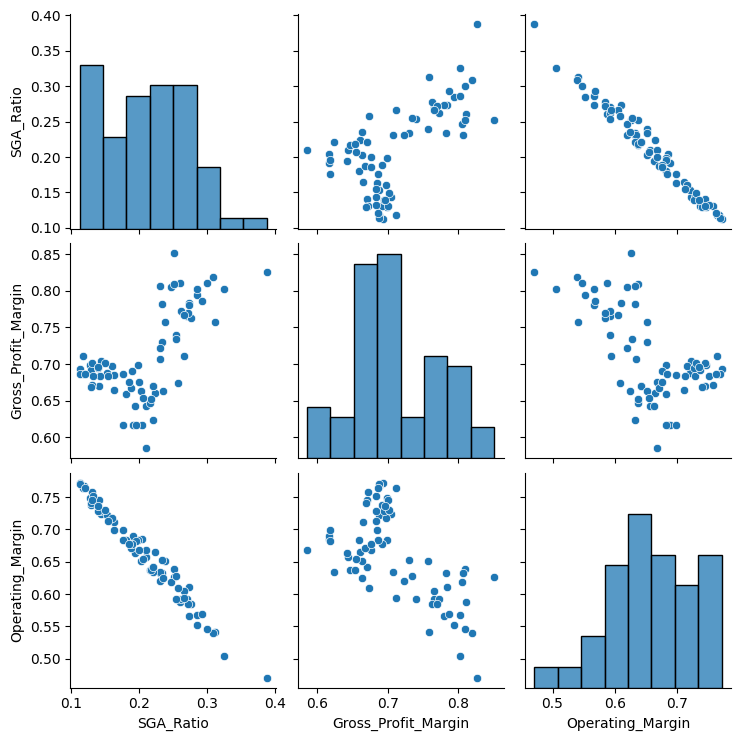

In [170]:
data = pd.DataFrame({
    'PER' : PER_m_array_22,
    'Gross_Profit_Margin' : Gross_Profit_Margin_m_array,
    'SGA_Ratio' : SGA_Ratio_m_array,
    'Operating_Margin' : Operating_Margin_m_array
})

y = data['PER']
x = data[['SGA_Ratio', 'Gross_Profit_Margin','Operating_Margin']]

X = sm.add_constant(x)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

#Checken der Multikollinearität durch Scatter Plot
sns.pairplot(data[['SGA_Ratio','Gross_Profit_Margin','Operating_Margin']])
plt.show()


#### Gross Profit Margin und SGA Ratio beeinflussen das PER wirklich wegen kleiner p-Werte.
* #### Operating Margin ist statistisch nicht relevant, weil er fast die gleiche Information wie die anderen beiden liefert (Scatter Plot zeigt eine Linie).
* #### Ein sehr hoher R² bedeutet, dass die Variablen sich zu ähnlich sind und die Modellqualität leidet.
* #### Das PER wird vor allem durch die Bruttomarge und SGA beeinflusst. Das 'Operating Margin' bringt in diesem Modell keinen zusätzlichen Erklärungswert, weil das sich aus denselben Größen zusammensetzt. 
#### Damit zeigt die Analyse: 
* #### Für Investoren ist entscheidend, wie viel Gross Profit Margin noch bleibt und wie effizient das Unternehmen SGA Ratio steuert.

# Schlussezusage

#### Nach mehreren Wochen intensiver Teamarbeit haben wir die Finanzdaten von Microsoft, Jenoptik und Apple analysiert und verglichen. Unser Ziel war es, mit verschiedenen Methoden die Stärken und Schwächen der Unternehmen herauszuarbeiten und ihre Marktposition objektiv zu bewerten.

#### Ein wichtiger Teil war die Entwicklung und Überprüfung von Hypothesen: Wir haben analysiert, welche Finanzkennzahlen das Kurs-Gewinn-Verhältnis (PER) und die operative Marge am stärksten beeinflussen. Mithilfe von Regressionsanalysen und Multikollinearitäts-Checks konnten wir zeigen, dass nicht alle Kennzahlen unabhängig voneinander wirken und die Auswahl der richtigen Variablen entscheidend ist.

#### Unsere Ergebnisse:

* #### Microsoft: Klare Wachstumsstrategie durch Investitionen in KI und Cloud, hohe Effizienz, aber zuletzt sinkender ROE.
* #### Jenoptik: Stabilität und stabile Margen, kontinuierlich reduzierte Verschuldung, starke operative Marge. Wachstum verringert sich.
* #### Apple: Extrem hohe Kapitalrendite und Verschuldung als Teil der Strategie, stabile Gewinne dank Markenstärke.
* #### Methodisch haben wir gezeigt, wie moderne Datenanalysemethoden und ein hypothesengetriebener Ansatz helfen, die Finanzkraft und Wettbewerbsfähigkeit von Unternehmen einzuschätzen. Die Ergebnisse unterstützen Investoren bei fundierten Entscheidungen.

#### Für die Zukunft planen wir, die Analyse auf weitere Unternehmen und Branchen auszuweiten, neue Hypothesen zu entwickeln und die Methoden weiter zu verfeinern.